17


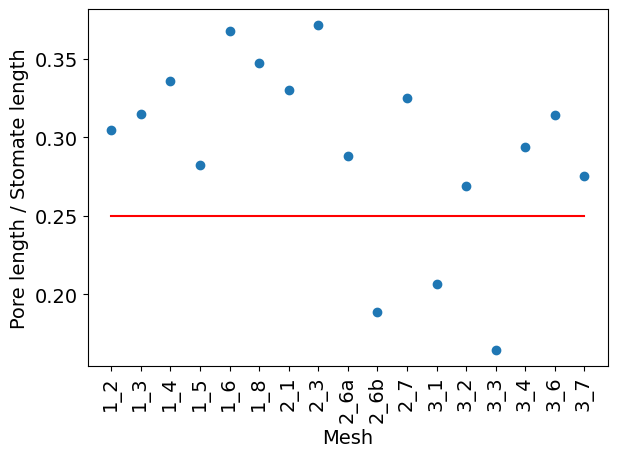

Selected meshes: ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']


In [1]:
## Load in the confocal data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Results dataframes
confocal_df = pd.read_csv("../output/confocal_results_df_batch.csv")
idealised_df = pd.read_csv("../output/idealised_chosen_results.csv")

## Set the colours for the three mesh types
colours = {
    'empirical': 'magenta',
    'anisotropic': "#8A0CA1",
    'idealised_circular': 'orange',
    'idealised_oval': 'green',
    'midsection' : 'black',
    'tip' : "#CC79A7"
}

# Set the default font size for all plots
plt.rcParams.update({'font.size': 14})

## Set the name for each mesh
mesh_dcr = "Sample"

## Choose meshes to include based on their pore length : length
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]
mesh_ids =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
print(len(mesh_ids))

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

plt.plot(mesh_ids, pore_proportion, 'o')
xs = np.arange(0,len(stomata_length))
ys = np.ones(len(xs)) * 0.25
plt.plot(xs,ys,'r-')

plt.xlabel('Mesh')
plt.ylabel('Pore length / Stomate length')
plt.xticks(rotation=90)
plt.tight_layout() 
plt.savefig("mesh_selection.png")
plt.show()

## Based on this plot, let's take a threshold of 0.25

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]
selected_meshes = [m for m, keep in zip(mesh_ids, prop_mask) if keep]
print("Selected meshes:", selected_meshes)


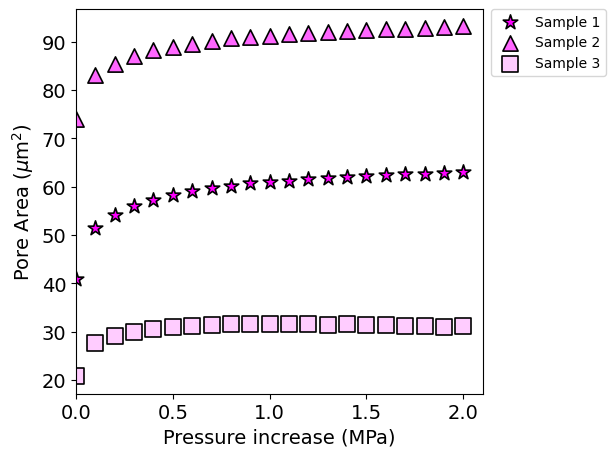

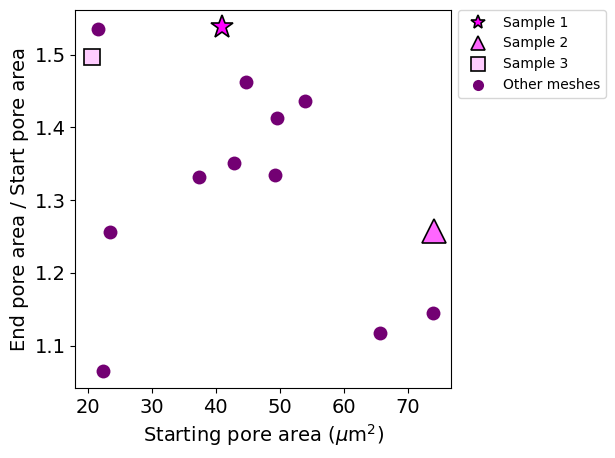

In [2]:
## Figure 1
import importlib
import plot_fig1 as pf1
importlib.reload(pf1)

pf1.run_plot_fig1(confocal_df=confocal_df, colours=colours, mesh_dcr=mesh_dcr)

Paired t-test: p = 1.6e-07
Wilcoxon signed-rank: p = 2.46e-07


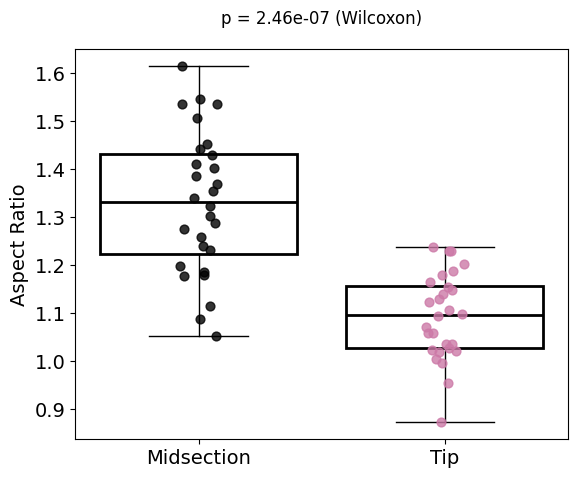

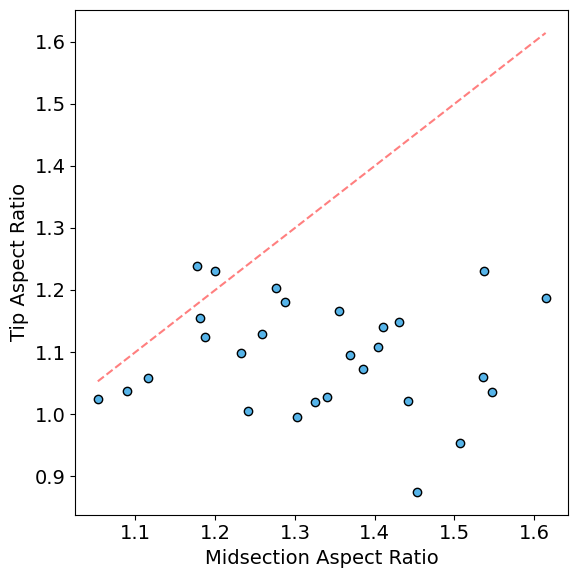

In [3]:
## Plot Figure 2
import importlib
import plot_fig2 as pf2
importlib.reload(pf2)
pf2.run_plot_fig2(confocal_df=confocal_df, colours=colours)



In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
## Figure 3: 
## a) Cross-sectional aspect ratio drives geometry-derived stomatal opening

## Load in the idealised results
df_idealised = pd.read_csv("../output/idealised_results_df.csv")
df_idealised_pore_area = pd.read_csv("../output/idealised_results_pore_area_df.csv")
df_idealised_cross_section = pd.read_csv("../output/idealised_results_cross_sections_df.csv")

## Combine our dataframes into a single dataframe
df_combined = df_idealised_pore_area.merge(df_idealised_cross_section, on=["Mesh ID", "Pressure", "Cross-section type"])

df_combined.head()

,Mesh ID,Cross-section type,Pressure,Pore Area,Cross section,Aspect Ratio
0,2_6a,circular,0.8,19.8944,[[-1.89380e+00 3.70945e-06]\n [-1.89773e+00 ...,0.954685
1,1_2,circular,0.0,40.9739,[[-2.81262 0. ]\n [-2.81671 0.260701]...,1.000519
2,3_4,circular,1.6,18.0763,[[-1.33900e+00 -6.69476e-04]\n [-1.34326e+00 ...,0.953271
3,2_1,oval,1.7,80.5220,[[-4.81271e+00 1.47737e-04]\n [-4.81541e+00 ...,1.041856
4,1_8,circular,1.1,61.9714,[[-3.56219e+00 -2.04021e-07]\n [-3.56594e+00 ...,0.958226


Skipping mesh 3_7 due to missing start or end data in idealised circular.


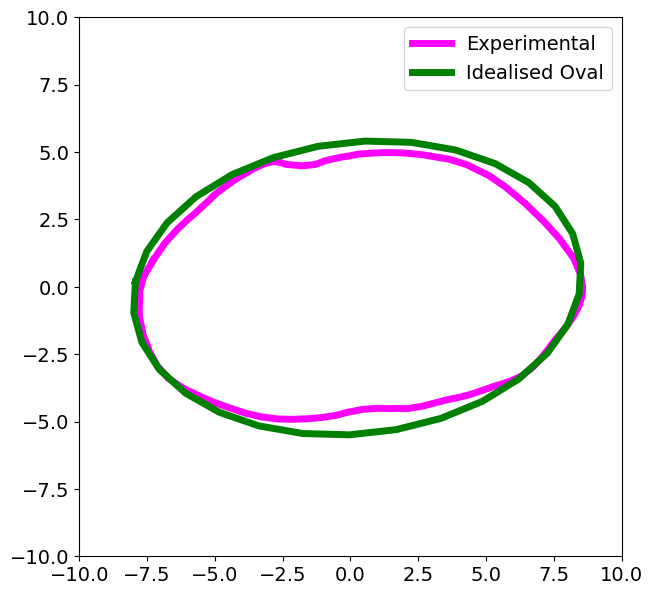

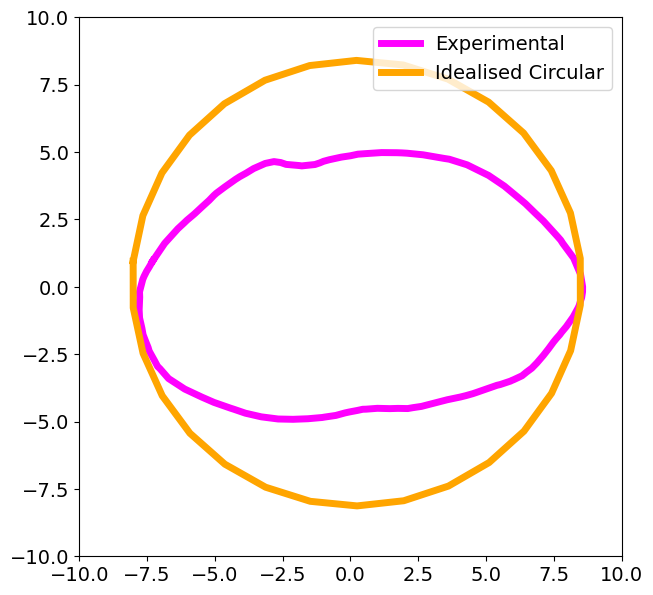

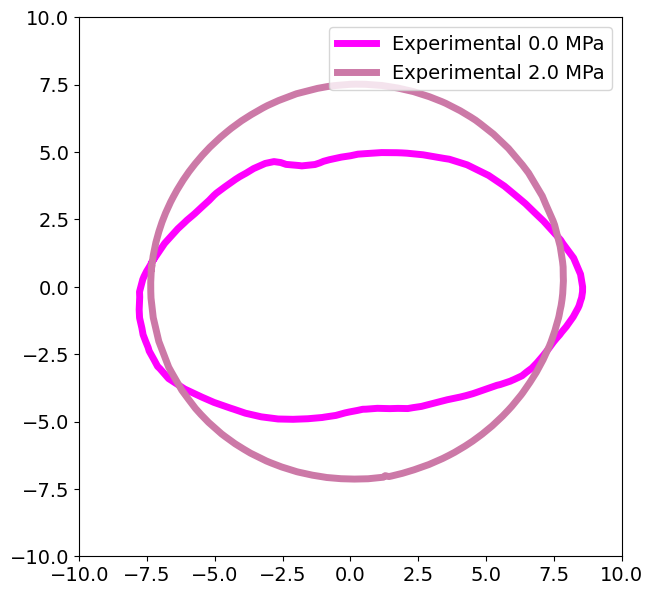

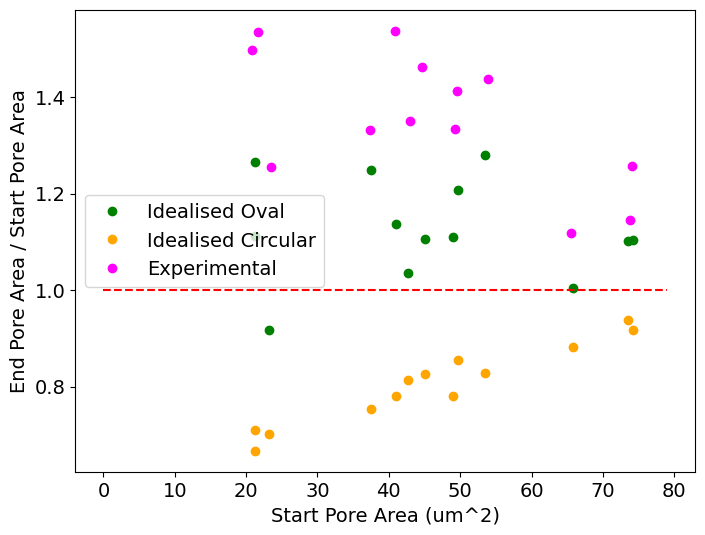

Skipping mesh 3_7 due to missing start or end data in idealised circular.
Oval: Linear regression: slope = 0.461 ± 0.164, intercept = 0.502, Pearson r = 0.646, p-value = 0.0171
Empirical: Linear regression: slope = 0.564 ± 0.246, intercept = 0.600, Pearson r = 0.568, p-value = 0.0427


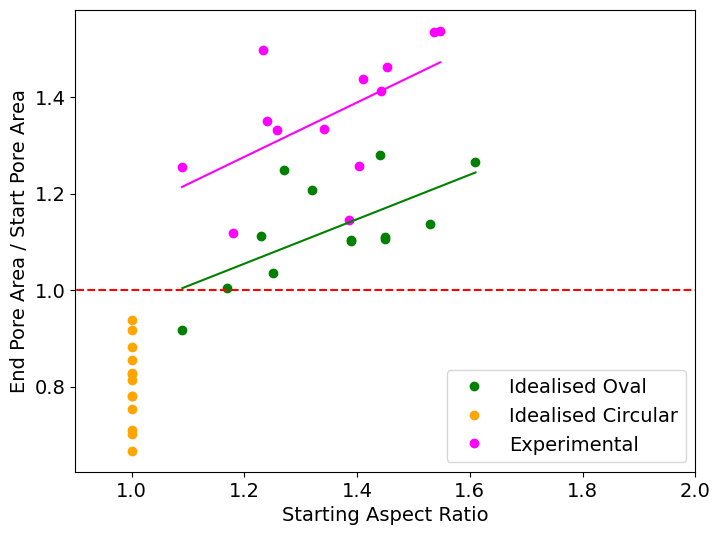

Skipping mesh 3_7 due to missing start or end data in idealised circular.


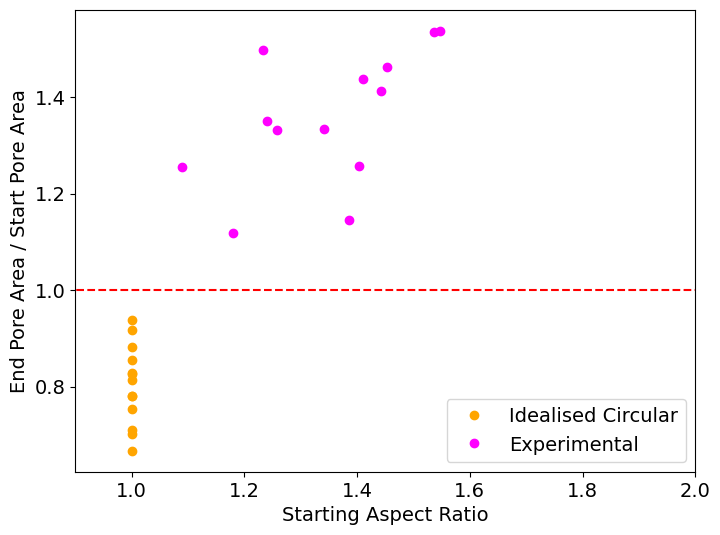

In [5]:
## Figure 3

import importlib
import plot_fig3 as pf3
importlib.reload(pf3)

oval_path = "../Meshes/Idealised/idealised_final_1_2_oval.ply"
circular_path = "../Meshes/Idealised/idealised_final_1_2_circular.ply"
pf3.run_plot_fig3(idealised_df=idealised_df, colours=colours, oval_path=oval_path, circular_path=circular_path, confocal_df=confocal_df, df_combined = df_combined, selected_meshes=selected_meshes)

## Let's also plot a version that doesn't include the oval data, for Figure 2.
pf3.AR_area_change_no_oval(selected_meshes, df_combined=df_combined, confocal_df = confocal_df, colours = colours)

In [6]:
## Figure 4: Anisotropy
## Plot guard cell length - does this change with inflation?
## Anisotropy - how does this affect opening dynamics?
## Can we show that initial differences in opening are due to geometry, whereas later differences are due to anisotropy?
## Which morphospace do plants need to live in?
import sys
from pathlib import Path
import pandas as pd

src_path = str(Path.cwd().parent / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import cross_section_helpers as csh
import importlib
importlib.reload(csh)
from mesh_functions import process_mesh_pressure
import numpy as np
from concurrent.futures import ProcessPoolExecutor

# Use linspace or round arange to avoid floating-point issues
pressures = np.round(np.arange(0, 2.1, 0.1), 1)

midsection_areas = pd.read_csv("../output/midsection_areas.csv")
area_map = {row['mesh_file']: (row['midsection_area1'], row['midsection_area2']) for _, row in midsection_areas.iterrows()}

# Validate that all selected meshes have area data
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    if mesh_file not in area_map:
        print(f"WARNING: No midsection area data found for {mesh_file}")

## Set up whether isotropic or anisotropic
stiffening = "isotropic"

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    if area1 is None or area2 is None:
        print(f"WARNING: Missing area data for {mesh}, using None")
    for p in pressures:
        tasks.append((mesh, p, area1, area2, stiffening))

results_matrix_iso = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix_iso[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results_iso = [list(row) for row in results_matrix_iso]

## Repeat for anisotropic stiffening
stiffening = "anisotropic"

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    for p in pressures:
        tasks.append((mesh, p, area1, area2, stiffening))

results_matrix_aniso = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix_aniso[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results_aniso = [list(row) for row in results_matrix_aniso]

Checking results_matrix_iso for zeros or NaNs:
  Zeros: 0
  NaNs: 0
  Shape: (14, 21)
  Min value: 66.281352620505
  Max value: 83.59762973972832

Checking results_matrix_aniso for zeros or NaNs:
  Zeros: 0
  NaNs: 0
  Shape: (14, 21)
  Min value: 64.55877750284435
  Max value: 85.17992885258539


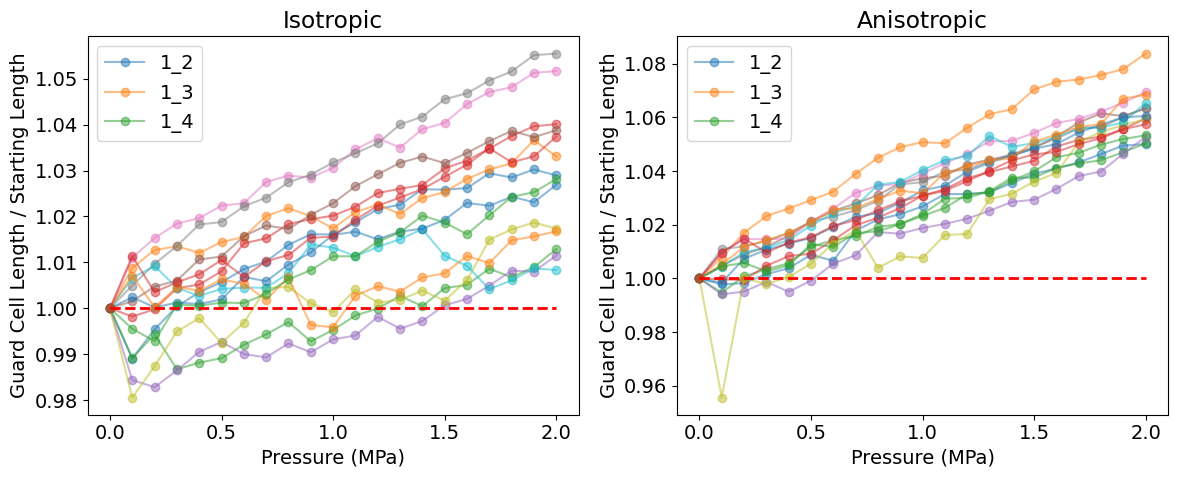


Number of valid samples at each pressure:
ISO: [14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14]
ANISO: [14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14 14]


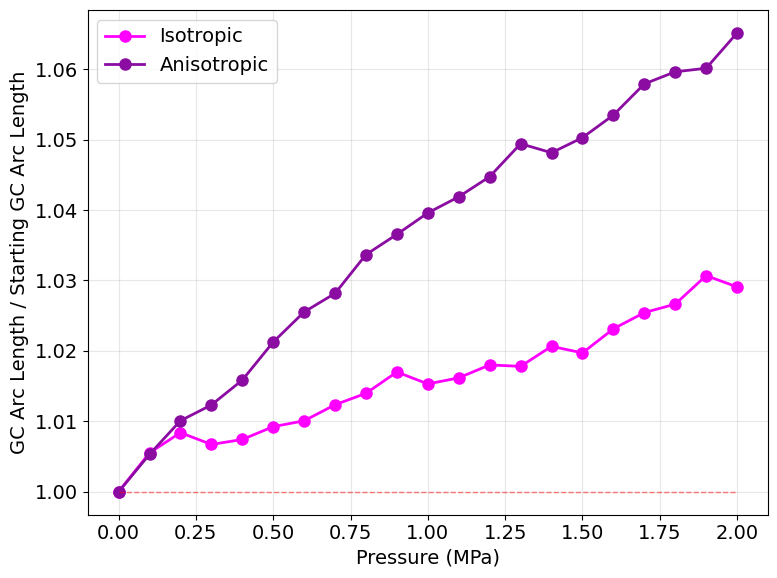

In [7]:
## First, let's check for any problematic values in the results matrices
print("Checking results_matrix_iso for zeros or NaNs:")
print(f"  Zeros: {np.sum(results_matrix_iso == 0)}")
print(f"  NaNs: {np.sum(np.isnan(results_matrix_iso))}")
print(f"  Shape: {results_matrix_iso.shape}")
print(f"  Min value: {np.nanmin(results_matrix_iso)}")
print(f"  Max value: {np.nanmax(results_matrix_iso)}")

print("\nChecking results_matrix_aniso for zeros or NaNs:")
print(f"  Zeros: {np.sum(results_matrix_aniso == 0)}")
print(f"  NaNs: {np.sum(np.isnan(results_matrix_aniso))}")
print(f"  Shape: {results_matrix_aniso.shape}")
print(f"  Min value: {np.nanmin(results_matrix_aniso)}")
print(f"  Max value: {np.nanmax(results_matrix_aniso)}")

# Check if any rows are all zeros (indicating a completely failed mesh)
iso_failed_meshes = np.where(np.all(results_matrix_iso == 0, axis=1))[0]
aniso_failed_meshes = np.where(np.all(results_matrix_aniso == 0, axis=1))[0]

if len(iso_failed_meshes) > 0:
    print(f"\nISO: Meshes with all zeros: {[selected_meshes[i] for i in iso_failed_meshes]}")
if len(aniso_failed_meshes) > 0:
    print(f"ANISO: Meshes with all zeros: {[selected_meshes[i] for i in aniso_failed_meshes]}")

## Plot stomata length vs pressure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Isotropic
for i, output in enumerate(results_iso):
    if output[0] != 0:  # Only plot if we have valid starting value
        ax1.plot(pressures, output / output[0], 'o-', alpha=0.5, label=selected_meshes[i] if i < 3 else None)
    else:
        print(f"WARNING: Mesh {selected_meshes[i]} has zero starting length (iso)")

ax1.plot(pressures, np.ones(len(pressures)), 'r--', linewidth=2)
ax1.set_xlabel("Pressure (MPa)")
ax1.set_ylabel("Guard Cell Length / Starting Length")
ax1.set_title("Isotropic")
ax1.legend()

# Anisotropic
for i, output in enumerate(results_aniso):
    if output[0] != 0:  # Only plot if we have valid starting value
        ax2.plot(pressures, output / output[0], 'o-', alpha=0.5, label=selected_meshes[i] if i < 3 else None)
    else:
        print(f"WARNING: Mesh {selected_meshes[i]} has zero starting length (aniso)")

ax2.plot(pressures, np.ones(len(pressures)), 'r--', linewidth=2)
ax2.set_xlabel("Pressure (MPa)")
ax2.set_ylabel("Guard Cell Length / Starting Length")
ax2.set_title("Anisotropic")
ax2.legend()

plt.tight_layout()
plt.savefig("guard_cell_length_change_both.png", dpi=300)
plt.show()

## Plot the median value for the iso and anisotropic meshes
# Use nanmedian to ignore NaN values, and mask out zeros
results_matrix_iso_masked = np.where(results_matrix_iso == 0, np.nan, results_matrix_iso)
results_matrix_aniso_masked = np.where(results_matrix_aniso == 0, np.nan, results_matrix_aniso)

median_values_iso = np.nanmedian(results_matrix_iso_masked, axis=0)
median_values_aniso = np.nanmedian(results_matrix_aniso_masked, axis=0)

# Check how many valid samples we have at each pressure
n_valid_iso = np.sum(~np.isnan(results_matrix_iso_masked), axis=0)
n_valid_aniso = np.sum(~np.isnan(results_matrix_aniso_masked), axis=0)

print(f"\nNumber of valid samples at each pressure:")
print(f"ISO: {n_valid_iso}")
print(f"ANISO: {n_valid_aniso}")

plt.figure(figsize=(8, 6))
plt.plot(pressures, median_values_iso / median_values_iso[0], 'o-', color=colours['empirical'], 
         label='Isotropic', markersize=8, linewidth=2)
plt.plot(pressures, median_values_aniso / median_values_aniso[0], 'o-', color=colours['anisotropic'], 
         label='Anisotropic', markersize=8, linewidth=2)
plt.plot(pressures, np.ones(len(pressures)), 'r--', linewidth=1, alpha=0.5)
plt.xlabel("Pressure (MPa)")
plt.ylabel("GC Arc Length / Starting GC Arc Length")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("median_guard_cell_length_change.png", dpi=300)
plt.show()

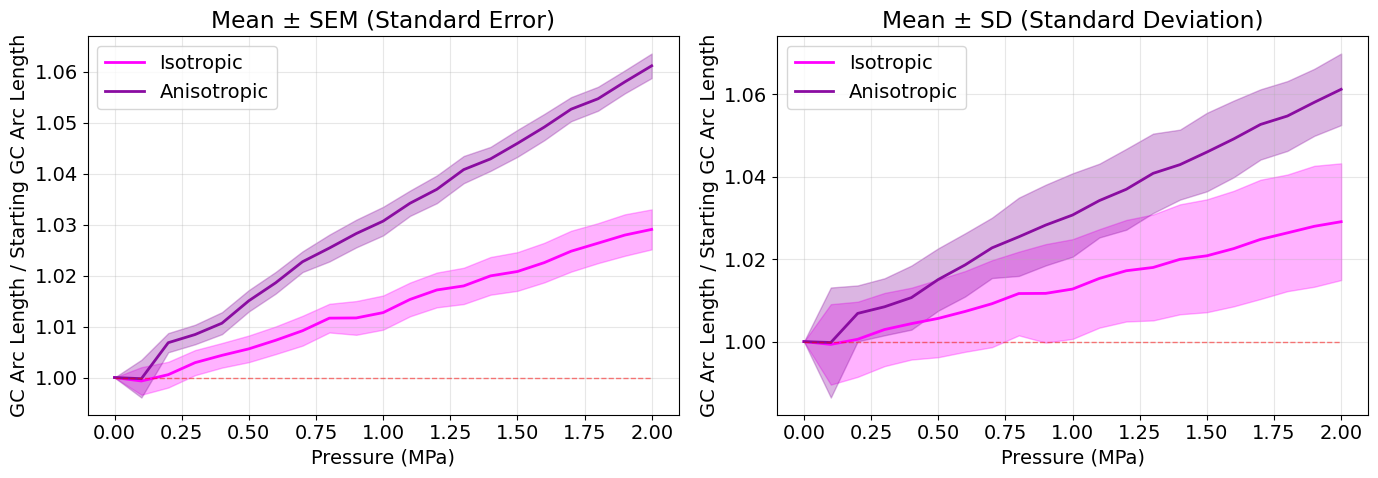

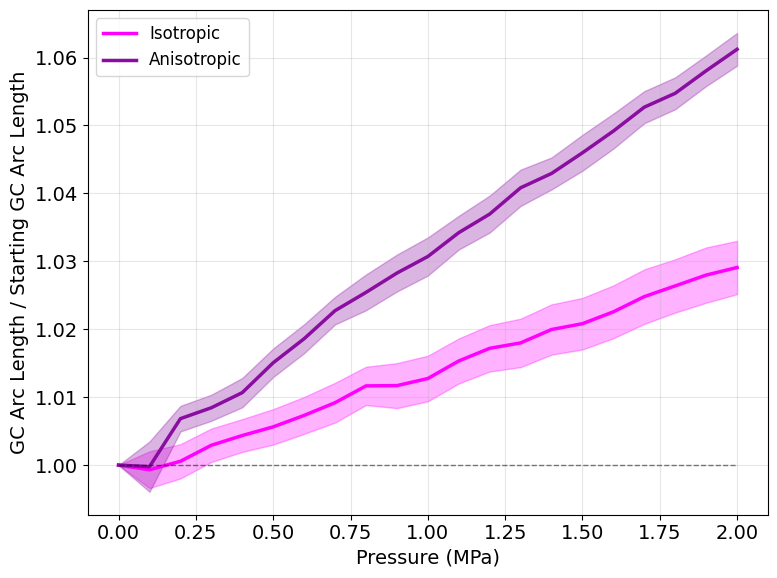

Number of meshes contributing: 14


In [7]:
## Plot mean with error bands (standard error and standard deviation)
from scipy import stats

# Mask out zeros and compute statistics
results_matrix_iso_masked = np.where(results_matrix_iso == 0, np.nan, results_matrix_iso)
results_matrix_aniso_masked = np.where(results_matrix_aniso == 0, np.nan, results_matrix_aniso)

# Normalize by starting length for each mesh
results_matrix_iso_norm = results_matrix_iso_masked / results_matrix_iso_masked[:, 0:1]
results_matrix_aniso_norm = results_matrix_aniso_masked / results_matrix_aniso_masked[:, 0:1]

# Compute mean and standard error
mean_iso = np.nanmean(results_matrix_iso_norm, axis=0)
sem_iso = stats.sem(results_matrix_iso_norm, axis=0, nan_policy='omit')
sd_iso = np.nanstd(results_matrix_iso_norm, axis=0)

mean_aniso = np.nanmean(results_matrix_aniso_norm, axis=0)
sem_aniso = stats.sem(results_matrix_aniso_norm, axis=0, nan_policy='omit')
sd_aniso = np.nanstd(results_matrix_aniso_norm, axis=0)

# Create two plots: one with SEM, one with SD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean ± SEM
ax1.plot(pressures, mean_iso, '-', color=colours['empirical'], linewidth=2, label='Isotropic')
ax1.fill_between(pressures, mean_iso - sem_iso, mean_iso + sem_iso, 
                  color=colours['empirical'], alpha=0.3)

ax1.plot(pressures, mean_aniso, '-', color=colours['anisotropic'], linewidth=2, label='Anisotropic')
ax1.fill_between(pressures, mean_aniso - sem_aniso, mean_aniso + sem_aniso, 
                  color=colours['anisotropic'], alpha=0.3)

ax1.plot(pressures, np.ones(len(pressures)), 'r--', linewidth=1, alpha=0.5)
ax1.set_xlabel("Pressure (MPa)")
ax1.set_ylabel("GC Arc Length / Starting GC Arc Length")
ax1.set_title("Mean ± SEM (Standard Error)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Mean ± SD
ax2.plot(pressures, mean_iso, '-', color=colours['empirical'], linewidth=2, label='Isotropic')
ax2.fill_between(pressures, mean_iso - sd_iso, mean_iso + sd_iso, 
                  color=colours['empirical'], alpha=0.3)

ax2.plot(pressures, mean_aniso, '-', color=colours['anisotropic'], linewidth=2, label='Anisotropic')
ax2.fill_between(pressures, mean_aniso - sd_aniso, mean_aniso + sd_aniso, 
                  color=colours['anisotropic'], alpha=0.3)

ax2.plot(pressures, np.ones(len(pressures)), 'r--', linewidth=1, alpha=0.5)
ax2.set_xlabel("Pressure (MPa)")
ax2.set_ylabel("GC Arc Length / Starting GC Arc Length")
ax2.set_title("Mean ± SD (Standard Deviation)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("guard_cell_length_mean_with_errors.png", dpi=300)
plt.show()

# Also create a single publication-quality plot with SEM (recommended)
plt.figure(figsize=(8, 6))
plt.plot(pressures, mean_iso, '-', color=colours['empirical'], linewidth=2.5, label='Isotropic')
plt.fill_between(pressures, mean_iso - sem_iso, mean_iso + sem_iso, 
                  color=colours['empirical'], alpha=0.3)

plt.plot(pressures, mean_aniso, '-', color=colours['anisotropic'], linewidth=2.5, label='Anisotropic')
plt.fill_between(pressures, mean_aniso - sem_aniso, mean_aniso + sem_aniso, 
                  color=colours['anisotropic'], alpha=0.3)

plt.plot(pressures, np.ones(len(pressures)), 'k--', linewidth=1, alpha=0.5)
plt.xlabel("Pressure (MPa)")
plt.ylabel("GC Arc Length / Starting GC Arc Length")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("guard_cell_length_mean_sem.png", dpi=300)
plt.show()

print(f"Number of meshes contributing: {np.sum(~np.isnan(results_matrix_iso_norm[:, 0]))}")

In [8]:
## Let's plot guard cell width and guard cell height before and after inflation for confocal and idealised meshes

import cross_section_helpers as csh
import os
from pathlib import Path

mesh_dir = Path("../Meshes/Onion meshes/pressure_results/")
mesh_paths = [mesh_dir / name for name in os.listdir(mesh_dir) if name.endswith(".obj")]

results = csh.batch_midsection_width_height(mesh_paths, guard_cell="both")


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import re

def _parse_mesh_metadata(mesh_entry):
    stem = Path(mesh_entry).stem
    parts = stem.split("_")
    if len(parts) < 2:
        raise ValueError(f"Cannot parse pressure token from {stem}")
    pressure_token = parts[-1]
    try:
        pressure = float(pressure_token)
    except ValueError as exc:
        raise ValueError(f"Could not convert pressure '{pressure_token}' in {stem}") from exc
    id_match = re.search(r"\d+_\d+", stem)
    if id_match:
        mesh_id = id_match.group(0)
    else:
        mesh_id = parts[0]
    return mesh_id, pressure

records = []
for row in results:
    if "error" in row:
        print(f"Skipping {row['mesh']}: {row['error']}")
        continue
    try:
        mesh_id, pressure = _parse_mesh_metadata(row["mesh"])
        print(mesh_id, pressure)
    except ValueError as exc:
        print(exc)
        continue
    if mesh_id not in selected_meshes:
        continue
    records.append({
        "mesh_id": mesh_id,
        "pressure": pressure,
        "left_width": row.get("left_width", 0.0),
        "left_height": row.get("left_height", 0.0),
        "right_width": row.get("right_width", 0.0),
        "right_height": row.get("right_height", 0.0),
    })

if not records:
    print("No valid midsection measurements available for selected meshes. Re-run the previous cell?")
else:
    df_midsections = pd.DataFrame(records)
    df_midsections["width_mean"] = (df_midsections["left_width"] + df_midsections["right_width"]) / 2
    df_midsections["height_mean"] = (df_midsections["left_height"] + df_midsections["right_height"]) / 2
    df_midsections = df_midsections.sort_values(["mesh_id", "pressure"]).reset_index(drop=True)
    display(df_midsections)


1_2 1.5
2_3 1.8
1_3 1.0
1_8 0.6
2_7 1.0
3_6 0.6
3_4 1.3
1_4 0.8
3_7 0.3
3_7 0.2
1_4 0.9
3_4 1.2
3_6 0.7
3_7 2.0
2_7 1.1
1_8 0.7
1_3 1.1
2_3 1.9
1_2 1.4
1_2 1.6
1_3 1.3
3_3 0.8
1_8 0.5
2_7 1.3
3_6 0.5
3_4 1.0
3_7 0.0
3_7 0.1
3_4 1.1
3_6 0.4
2_7 1.2
1_8 0.4
3_3 0.9
1_3 1.2
1_2 1.7
3_1 1.8
3_2 0.8
1_2 1.3
1_3 1.6
1_8 0.0
3_6 0.0
2_7 1.6
3_4 1.5
3_7 0.5
3_7 0.4
3_4 1.4
2_7 1.7
3_6 0.1
1_8 0.1
1_3 1.7
1_2 1.2
3_2 0.9
3_1 1.9
1_2 1.0
2_1 0.8
1_3 1.5
1_5 0.8
1_8 0.3
2_6 1.8
1_6 1.8
3_6 0.3
2_6 0.8
2_7 1.5
3_4 1.6
3_7 0.6
3_6 2.0
3_7 0.7
1_8 2.0
3_4 1.7
2_7 1.4
2_6 0.9
3_6 0.2
1_6 1.9
2_6 1.9
1_8 0.2
1_5 0.9
1_3 1.4
2_1 0.9
1_2 1.1
3_4 0.0
3_7 1.0
1_8 1.5
2_7 0.3
3_6 1.5
1_3 0.3
3_3 1.8
1_2 0.6
1_2 0.7
1_3 2.0
3_3 1.9
1_3 0.2
3_6 1.4
2_7 0.2
1_8 1.4
3_7 1.1
2_7 2.0
3_4 0.1
3_4 0.3
1_4 1.8
3_7 1.3
1_8 1.6
2_7 0.0
3_6 1.6
1_3 0.0
1_2 0.5
2_3 0.8
2_3 0.9
1_2 0.4
1_3 0.1
3_6 1.7
2_7 0.1
3_4 2.0
1_8 1.7
3_7 1.2
1_4 1.9
3_4 0.2
3_4 0.6
3_7 1.6
1_5 1.8
1_8 1.3
2_6 0.8
1_6 0.8
3_6 1.3
2_6 1.8
2_7 0.5


,mesh_id,pressure,left_width,left_height,right_width,right_height,width_mean,height_mean
0,1_2,0.0,16.311106,10.086749,17.567968,10.643263,16.939537,10.365006
1,1_2,0.1,14.883586,12.113705,15.834589,12.618888,15.359087,12.366296
2,1_2,0.2,14.429426,12.564605,15.734825,12.887734,15.082125,12.726170
3,1_2,0.3,14.331670,12.826289,15.637421,13.185332,14.984545,13.005810
4,1_2,0.4,14.283505,13.028298,15.654058,13.410612,14.968781,13.219455
...,...,...,...,...,...,...,...,...
268,3_7,1.6,17.287522,17.519439,16.395980,16.185530,16.841751,16.852484
269,3_7,1.7,17.395866,17.599143,16.486946,16.266908,16.941406,16.933026
270,3_7,1.8,17.500821,17.679687,16.586341,16.343603,17.043581,17.011645
271,3_7,1.9,17.598272,17.763317,16.678044,16.425930,17.138158,17.094624


In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
from itertools import cycle

def _parse_mesh_pressure(mesh_entry):
    stem = Path(mesh_entry).stem
    parts = stem.split("_")
    if len(parts) < 2:
        raise ValueError(f"Cannot parse pressure token from {stem}")
    mesh_id = "_".join(parts[:-1])
    pressure_token = parts[-1]
    try:
        pressure = float(pressure_token)
    except ValueError as exc:
        raise ValueError(f"Could not convert pressure '{pressure_token}' in {stem}") from exc
    return mesh_id, pressure

records = []
for row in results:
    if "error" in row:
        print(f"Skipping {row['mesh']}: {row['error']}")
        continue
    try:
        mesh_id, pressure = _parse_mesh_pressure(row["mesh"])
    except ValueError as exc:
        print(exc)
        continue
    records.append({
        "mesh_id": mesh_id,
        "pressure": pressure,
        "left_width": row.get("left_width", 0.0),
        "left_height": row.get("left_height", 0.0),
        "right_width": row.get("right_width", 0.0),
        "right_height": row.get("right_height", 0.0),
    })

if not records:
    print("No valid midsection measurements available. Re-run the previous cell?")
else:
    df_midsections = pd.DataFrame(records)
    df_midsections["width_mean"] = (df_midsections["left_width"] + df_midsections["right_width"]) / 2
    df_midsections["height_mean"] = (df_midsections["left_height"] + df_midsections["right_height"]) / 2
    df_midsections = df_midsections.sort_values(["mesh_id", "pressure"]).reset_index(drop=True)
    display(df_midsections)

   

,mesh_id,pressure,left_width,left_height,right_width,right_height,width_mean,height_mean
0,Ac_DA_1_2,0.0,16.311106,10.086749,17.567968,10.643263,16.939537,10.365006
1,Ac_DA_1_2,0.1,14.883586,12.113705,15.834589,12.618888,15.359087,12.366296
2,Ac_DA_1_2,0.2,14.429426,12.564605,15.734825,12.887734,15.082125,12.726170
3,Ac_DA_1_2,0.3,14.331670,12.826289,15.637421,13.185332,14.984545,13.005810
4,Ac_DA_1_2,0.4,14.283505,13.028298,15.654058,13.410612,14.968781,13.219455
...,...,...,...,...,...,...,...,...
352,Ac_DA_3_7,1.6,17.287522,17.519439,16.395980,16.185530,16.841751,16.852484
353,Ac_DA_3_7,1.7,17.395866,17.599143,16.486946,16.266908,16.941406,16.933026
354,Ac_DA_3_7,1.8,17.500821,17.679687,16.586341,16.343603,17.043581,17.011645
355,Ac_DA_3_7,1.9,17.598272,17.763317,16.678044,16.425930,17.138158,17.094624


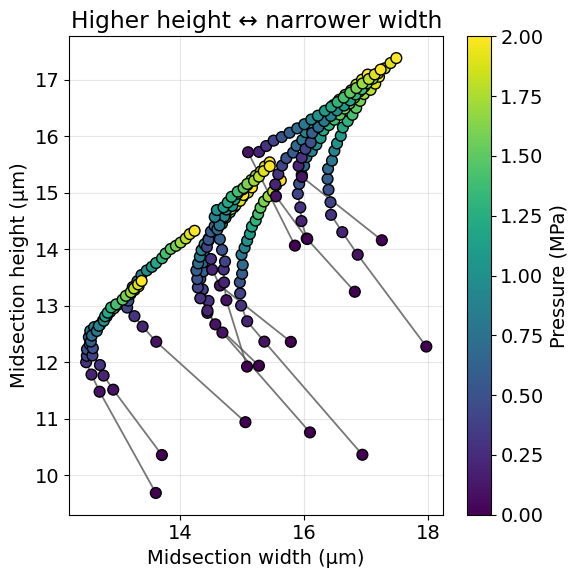

In [10]:
from matplotlib.patches import Patch
import numpy as np
import re

df_plot = df_midsections.copy()
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    df_plot["width_mean"],
    df_plot["height_mean"],
    c=df_plot["pressure"],
    cmap="viridis",
    s=60,
    edgecolor="k",
    zorder=3
 )

line_color = "#555555"
for mesh_id, subset in df_plot.groupby("mesh_id"):
    subset = subset.sort_values("pressure")
    if len(subset) < 2:
        continue
    ax.plot(
        subset["width_mean"],
        subset["height_mean"],
        color=line_color,
        linewidth=1.3,
        alpha=0.8,
        zorder=2
    )

ax.set_xlabel("Midsection width (μm)")
ax.set_ylabel("Midsection height (μm)")
ax.set_title("Higher height ↔ narrower width")
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax, label="Pressure (MPa)")
plt.tight_layout()

In [11]:
import cross_section_helpers as csh
import os
from pathlib import Path

mesh_dir = Path("../Meshes/Idealised/pressure_results/")
mesh_paths = [mesh_dir / name for name in os.listdir(mesh_dir) if name.endswith(".obj")]

## Only keep the oval meshes

mesh_paths = [path for path in mesh_paths if "oval" in path.stem]


results = csh.batch_midsection_width_height(mesh_paths, guard_cell="both")



,mesh_id,pressure,left_width,left_height,right_width,right_height,width_mean,height_mean
0,idealised_final_mdx_1_2_oval,0.0,16.599395,10.877638,16.599296,10.877573,16.599346,10.877606
1,idealised_final_mdx_1_2_oval,0.1,15.491708,12.515685,15.531814,12.515694,15.511761,12.515689
2,idealised_final_mdx_1_2_oval,0.2,15.469942,12.860688,15.478512,12.860563,15.474227,12.860626
3,idealised_final_mdx_1_2_oval,0.3,15.425759,13.110939,15.445253,13.109254,15.435506,13.110096
4,idealised_final_mdx_1_2_oval,0.4,15.425075,13.307456,15.424706,13.308621,15.424890,13.308038
...,...,...,...,...,...,...,...,...
269,idealised_final_mdx_3_6_oval,1.7,16.931180,17.063073,16.932369,17.063331,16.931775,17.063202
270,idealised_final_mdx_3_6_oval,1.8,17.016738,17.167083,17.016495,17.166863,17.016617,17.166973
271,idealised_final_mdx_3_6_oval,1.9,17.101816,17.267917,17.101692,17.268792,17.101754,17.268355
272,idealised_final_mdx_3_6_oval,2.0,17.186841,17.369091,17.186927,17.367646,17.186884,17.368368


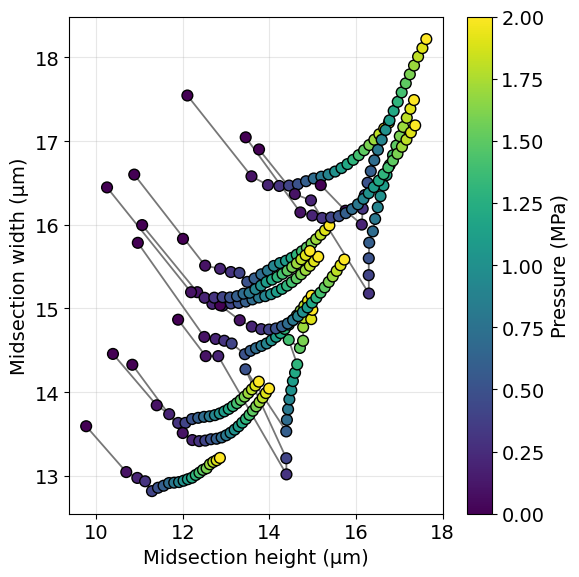

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(
    df_midsections["width_mean"],
    df_midsections["height_mean"],
    c=df_midsections["pressure"],
    cmap="viridis",
    s=60,
    edgecolor="k",
    zorder=3
 )

line_color = "#555555"
for mesh_id, subset in df_midsections.groupby("mesh_id"):
    subset = subset.sort_values("pressure")
    if len(subset) < 2:
        continue
    ax.plot(
        subset["width_mean"],
        subset["height_mean"],
        color=line_color,
        linewidth=1.3,
        alpha=0.8,
        zorder=2
    )

ax.set_xlabel("Midsection width (μm)")
ax.set_ylabel("Midsection height (μm)")
ax.grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=ax, label="Pressure (MPa)")
plt.tight_layout()
plt.savefig("midsection_height_width_oval.png", dpi=300)

In [60]:
## Let's look at the relationship between pore aspect ratio and change in pore area
import mesh_functions
importlib.reload(mesh_functions)
from mesh_functions import fast_pore_area_fast_ar
from pathlib import Path

results = []

for mesh in selected_meshes:
    mesh_path0 = Path(f"../Meshes/Idealised/pressure_results/idealised_final_mdx_{mesh}_circular_0.0.obj")
    mesh_path2 = Path(f"../Meshes/Idealised/pressure_results/idealised_final_mdx_{mesh}_circular_2.0.obj")
    try:
        row1 = fast_pore_area_fast_ar(mesh_path0)
        row2 = fast_pore_area_fast_ar(mesh_path2)
        results.append(row1)
        results.append(row2)
    except Exception as e:
        print(f"Error processing mesh {mesh}: {e}")

df = pd.DataFrame(results)


Error processing mesh 3_7: string is not a file: `/Users/tomkinsm/stomata-air-mattress/jupyter_notebooks/../Meshes/Idealised/pressure_results/idealised_final_mdx_3_7_circular_0.0.obj`


In [66]:
results = []

for mesh in selected_meshes:
    mesh_path0 = Path(f"../Meshes/Idealised/pressure_results/idealised_final_mdx_{mesh}_oval_0.0.obj")
    mesh_path2 = Path(f"../Meshes/Idealised/pressure_results/idealised_final_mdx_{mesh}_oval_2.0.obj")
    try:
        row1 = fast_pore_area_fast_ar(mesh_path0)
        row2 = fast_pore_area_fast_ar(mesh_path2)
        results.append(row1)
        results.append(row2)
    except Exception as e:
        print(f"Error processing mesh {mesh}: {e}")

df = pd.DataFrame(results)

Error processing mesh 3_7: string is not a file: `/Users/tomkinsm/stomata-air-mattress/jupyter_notebooks/../Meshes/Idealised/pressure_results/idealised_final_mdx_3_7_oval_2.0.obj`


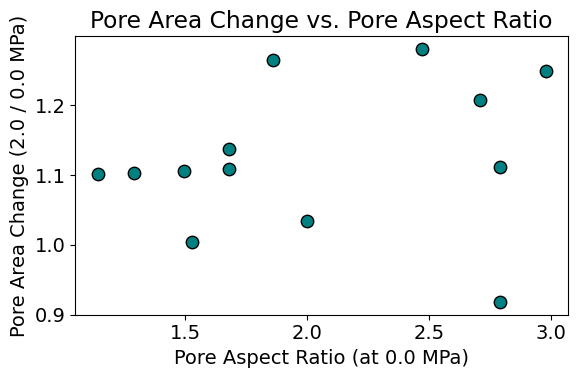

Pearson r = 0.204, p = 0.504
Spearman r = 0.330, p = 0.271


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

def _parse_mesh_pressure(mesh_entry):
    stem = Path(mesh_entry).stem
    parts = stem.split("_")
    if len(parts) < 2:
        raise ValueError(f"Cannot parse pressure token from {stem}")
    mesh_id = "_".join(parts[:-1])
    pressure_token = parts[-1]
    try:
        pressure = float(pressure_token)
    except ValueError as exc:
        raise ValueError(f"Could not convert pressure '{pressure_token}' in {stem}") from exc
    mesh_id_match = "_".join(parts[3:5]) if len(parts) >= 5 else mesh_id
    return mesh_id_match, pressure

records = []
for row in results:
    if "error" in row:
        print(f"Skipping {row['mesh']}: {row['error']}")
        continue
    try:
        mesh_id, pressure = _parse_mesh_pressure(row["mesh"])
    except ValueError as exc:
        print(exc)
        continue
    if mesh_id not in selected_meshes:
        continue
    records.append({
        "mesh_id": mesh_id,
        "pressure": pressure,
        "left_width": row.get("left_width", 0.0),
        "left_height": row.get("left_height", 0.0),
        "right_width": row.get("right_width", 0.0),
        "right_height": row.get("right_height", 0.0),
    })

if not records:
    print("No valid midsection measurements available for selected meshes. Re-run the previous cell?")
else:
    df_midsections = pd.DataFrame(records)
    df_midsections["width_mean"] = (df_midsections["left_width"] + df_midsections["right_width"]) / 2
    df_midsections["height_mean"] = (df_midsections["left_height"] + df_midsections["right_height"]) / 2
    df_midsections = df_midsections.sort_values(["mesh_id", "pressure"]).reset_index(drop=True)
    display(df_midsections)

    fig, ax = plt.subplots(figsize=(6, 6))
    sc = ax.scatter(
        df_midsections["height_mean"],
        df_midsections["width_mean"],
        c=df_midsections["pressure"],
        cmap="viridis",
        s=60,
        edgecolor="k",
        zorder=3
     )

    line_color = "#555555"
    for mesh_id, subset in df_midsections.groupby("mesh_id"):
        subset = subset.sort_values("pressure")
        if len(subset) < 2:
            continue
        ax.plot(
            subset["height_mean"],
            subset["width_mean"],
            color=line_color,
            linewidth=1.3,
            alpha=0.8,
            zorder=2
        )

    ax.set_xlabel("Midsection height (μm)")
    ax.set_ylabel("Midsection width (μm)")
    ax.grid(alpha=0.3)
    cbar = plt.colorbar(sc, ax=ax, label="Pressure (MPa)")
    plt.tight_layout()
    plt.savefig("midsection_height_width_oval.png", dpi=300)

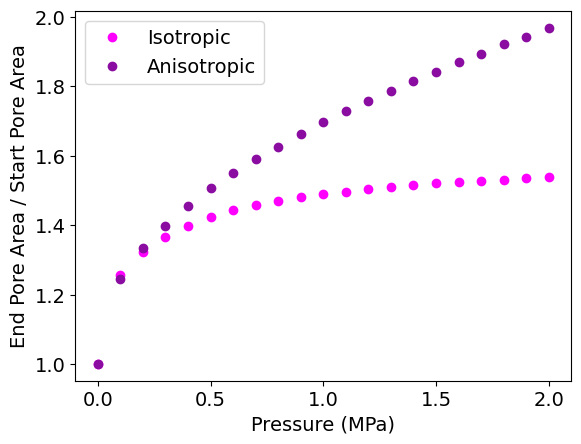

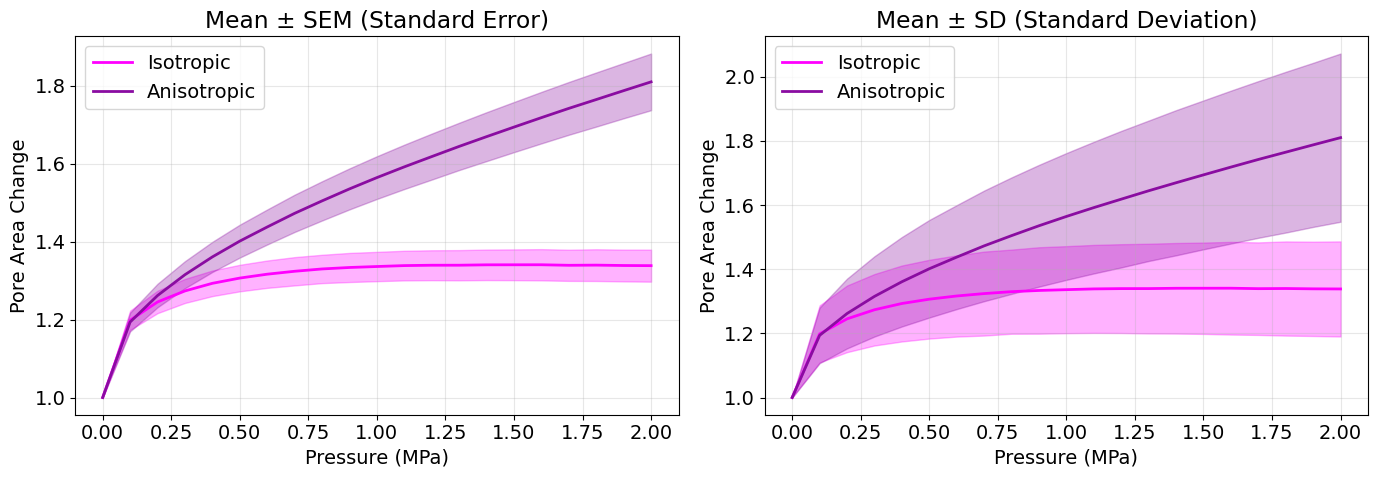

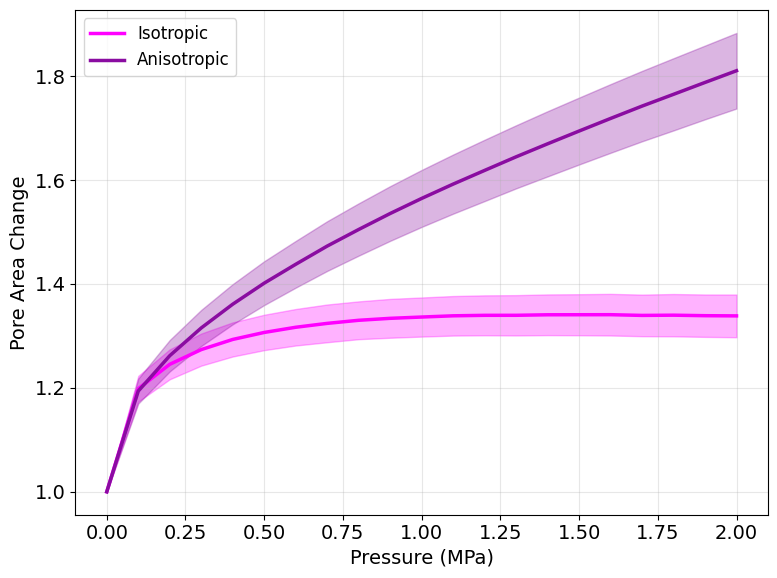

Number of meshes - Isotropic: 14, Anisotropic: 14


In [8]:
from scipy import stats

confocal_df_aniso = pd.read_csv("../output/confocal_aniso_results_df_batch.csv")

##Plot pressure vs change in pore area for confocal meshes with and without anisotropic stiffening
isotropic_handle = None
anisotropic_handle = None

this_mesh = selected_meshes[0]
for mesh in [this_mesh]:
    mesh_data_confocal = confocal_df[confocal_df["Mesh ID"].str.contains(mesh)]
    mesh_data_confocal_aniso = confocal_df_aniso[confocal_df_aniso["Mesh ID"].str.contains(mesh)]
    if mesh_data_confocal.empty or mesh_data_confocal_aniso.empty:
        print(f"Skipping mesh {mesh} due to missing data.")
        continue
    mesh_data_confocal_start = mesh_data_confocal[mesh_data_confocal["Pressure"] == 0.0]["Pore Area"].values[0]
    change_in_pore_area = (mesh_data_confocal["Pore Area"].values / mesh_data_confocal_start)
    h1, = plt.plot(mesh_data_confocal["Pressure"], change_in_pore_area, 'o', color=colours['empirical'], label=None)
    if isotropic_handle is None:
        isotropic_handle = h1
    mesh_data_confocal_aniso_start = mesh_data_confocal_aniso[mesh_data_confocal_aniso["Pressure"] == 0.0]["Pore Area"].values[0]
    change_in_pore_area_aniso = (mesh_data_confocal_aniso["Pore Area"].values / mesh_data_confocal_aniso_start)
    h2, = plt.plot(mesh_data_confocal_aniso["Pressure"], change_in_pore_area_aniso, 'o', color=colours['anisotropic'], label=None)
    if anisotropic_handle is None:
        anisotropic_handle = h2
plt.xlabel("Pressure (MPa)")
plt.ylabel("End Pore Area / Start Pore Area")
plt.legend([isotropic_handle, anisotropic_handle], ["Isotropic", "Anisotropic"] )
plt.savefig("iso_vs_aniso.png", dpi=300)
plt.show()

## Calculate normalized pore area change for all meshes
confocal_df["Pore Area Change"] = np.nan
confocal_df_aniso["Pore Area Change"] = np.nan

for mesh in selected_meshes:
    mesh_mask = confocal_df["Mesh ID"].str.contains(mesh)
    mesh_data = confocal_df[mesh_mask]
    start_area = mesh_data[mesh_data["Pressure"] == 0.0]["Pore Area"].values
    if len(start_area) == 0:
        continue
    start_area = start_area[0]
    confocal_df.loc[mesh_mask, "Pore Area Change"] = mesh_data["Pore Area"] / start_area

    mesh_mask_aniso = confocal_df_aniso["Mesh ID"].str.contains(mesh)
    mesh_data_aniso = confocal_df_aniso[mesh_mask_aniso]
    start_area_aniso = mesh_data_aniso[mesh_data_aniso["Pressure"] == 0.0]["Pore Area"].values
    if len(start_area_aniso) == 0:
        continue
    start_area_aniso = start_area_aniso[0]
    confocal_df_aniso.loc[mesh_mask_aniso, "Pore Area Change"] = mesh_data_aniso["Pore Area"] / start_area_aniso

pressures = np.round(np.arange(0, 2.1, 0.1), 1)

# Collect data into arrays for each pressure point
mean_values_iso = []
sem_values_iso = []
sd_values_iso = []
mean_values_aniso = []
sem_values_aniso = []
sd_values_aniso = []

for p in pressures:
    iso_data = confocal_df[confocal_df["Pressure"] == p]["Pore Area Change"].dropna().values
    aniso_data = confocal_df_aniso[confocal_df_aniso["Pressure"] == p]["Pore Area Change"].dropna().values
    
    if len(iso_data) > 0:
        mean_values_iso.append(np.mean(iso_data))
        sem_values_iso.append(stats.sem(iso_data))
        sd_values_iso.append(np.std(iso_data))
    else:
        mean_values_iso.append(np.nan)
        sem_values_iso.append(np.nan)
        sd_values_iso.append(np.nan)
    
    if len(aniso_data) > 0:
        mean_values_aniso.append(np.mean(aniso_data))
        sem_values_aniso.append(stats.sem(aniso_data))
        sd_values_aniso.append(np.std(aniso_data))
    else:
        mean_values_aniso.append(np.nan)
        sem_values_aniso.append(np.nan)
        sd_values_aniso.append(np.nan)

mean_values_iso = np.array(mean_values_iso)
sem_values_iso = np.array(sem_values_iso)
sd_values_iso = np.array(sd_values_iso)
mean_values_aniso = np.array(mean_values_aniso)
sem_values_aniso = np.array(sem_values_aniso)
sd_values_aniso = np.array(sd_values_aniso)

# Create comparison plots: Mean ± SEM vs Mean ± SD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean ± SEM
ax1.plot(pressures, mean_values_iso, '-', color=colours['empirical'], linewidth=2, label='Isotropic')
ax1.fill_between(pressures, mean_values_iso - sem_values_iso, mean_values_iso + sem_values_iso, 
                  color=colours['empirical'], alpha=0.3)

ax1.plot(pressures, mean_values_aniso, '-', color=colours['anisotropic'], linewidth=2, label='Anisotropic')
ax1.fill_between(pressures, mean_values_aniso - sem_values_aniso, mean_values_aniso + sem_values_aniso, 
                  color=colours['anisotropic'], alpha=0.3)

ax1.set_xlabel("Pressure (MPa)")
ax1.set_ylabel("Pore Area Change")
ax1.set_title("Mean ± SEM (Standard Error)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Mean ± SD
ax2.plot(pressures, mean_values_iso, '-', color=colours['empirical'], linewidth=2, label='Isotropic')
ax2.fill_between(pressures, mean_values_iso - sd_values_iso, mean_values_iso + sd_values_iso, 
                  color=colours['empirical'], alpha=0.3)

ax2.plot(pressures, mean_values_aniso, '-', color=colours['anisotropic'], linewidth=2, label='Anisotropic')
ax2.fill_between(pressures, mean_values_aniso - sd_values_aniso, mean_values_aniso + sd_values_aniso, 
                  color=colours['anisotropic'], alpha=0.3)

ax2.set_xlabel("Pressure (MPa)")
ax2.set_ylabel("Pore Area Change")
ax2.set_title("Mean ± SD (Standard Deviation)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pore_area_change_mean_with_errors.png", dpi=300)
plt.show()

# Publication-quality plot with SEM
plt.figure(figsize=(8, 6))
plt.plot(pressures, mean_values_iso, '-', color=colours['empirical'], linewidth=2.5, label='Isotropic')
plt.fill_between(pressures, mean_values_iso - sem_values_iso, mean_values_iso + sem_values_iso, 
                  color=colours['empirical'], alpha=0.3)

plt.plot(pressures, mean_values_aniso, '-', color=colours['anisotropic'], linewidth=2.5, label='Anisotropic')
plt.fill_between(pressures, mean_values_aniso - sem_values_aniso, mean_values_aniso + sem_values_aniso, 
                  color=colours['anisotropic'], alpha=0.3)

plt.xlabel("Pressure (MPa)")
plt.ylabel("Pore Area Change")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("iso_vs_aniso_mean_sem.png", dpi=300)
plt.show()

# Print sample sizes
n_iso = confocal_df[confocal_df["Pressure"] == 0.0]["Pore Area Change"].dropna().shape[0]
n_aniso = confocal_df_aniso[confocal_df_aniso["Pressure"] == 0.0]["Pore Area Change"].dropna().shape[0]
print(f"Number of meshes - Isotropic: {n_iso}, Anisotropic: {n_aniso}")

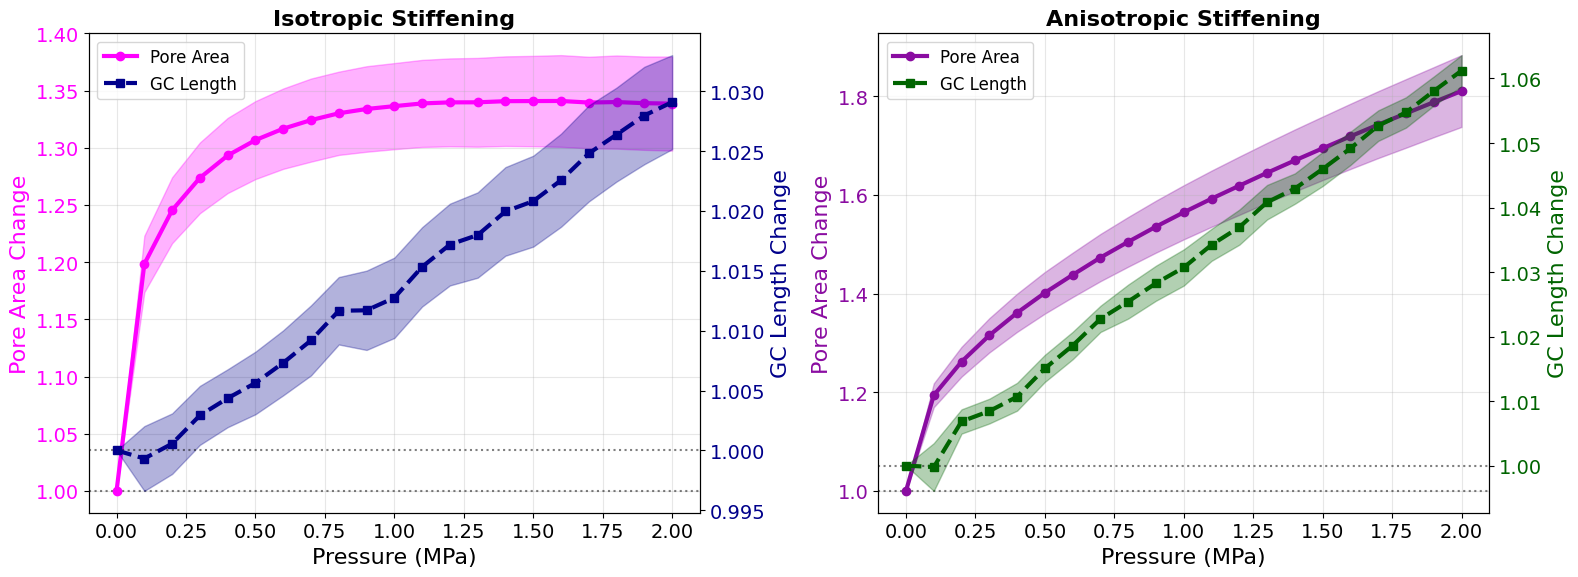

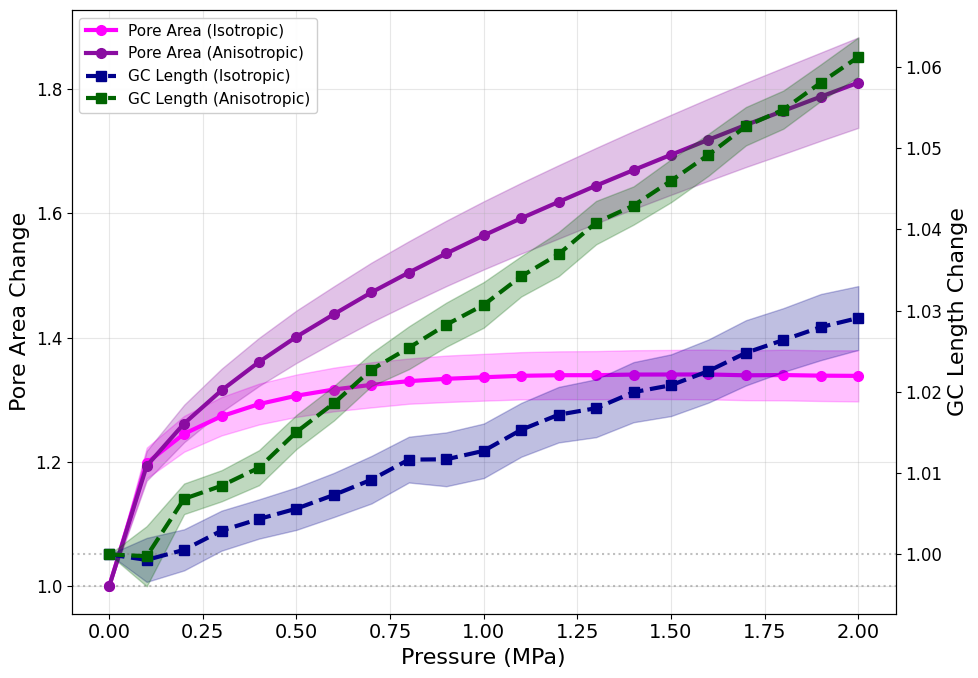


=== Summary Statistics ===
Final GC Length Change (Isotropic): 1.029 ± 0.004
Final GC Length Change (Anisotropic): 1.061 ± 0.002
Final Pore Area Change (Isotropic): 1.339 ± 0.041
Final Pore Area Change (Anisotropic): 1.810 ± 0.073

=== Ratio of Changes ===
Pore Area / GC Length (Isotropic): 11.64x
Pore Area / GC Length (Anisotropic): 13.24x


In [12]:
## Combined plot: Guard Cell Length and Pore Area Change with SEM
# Using dual y-axes for better visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ============ LEFT PANEL: Isotropic ============
# Create primary axis for Pore Area
ax1_pore = ax1
ax1_pore.plot(pressures, mean_values_iso, '-', color=colours['empirical'], linewidth=3, 
              label='Pore Area', zorder=3, marker='o', markersize=6)
ax1_pore.fill_between(pressures, mean_values_iso - sem_values_iso, mean_values_iso + sem_values_iso, 
                       color=colours['empirical'], alpha=0.3, zorder=1)
ax1_pore.set_xlabel("Pressure (MPa)", fontsize=16)
ax1_pore.set_ylabel("Pore Area Change", fontsize=16, color=colours['empirical'])
ax1_pore.tick_params(axis='y', labelcolor=colours['empirical'])

# Create secondary axis for GC Length
ax1_gc = ax1.twinx()
ax1_gc.plot(pressures, mean_iso, '--', color='darkblue', linewidth=3, 
            label='GC Length', zorder=3, marker='s', markersize=6)
ax1_gc.fill_between(pressures, mean_iso - sem_iso, mean_iso + sem_iso, 
                     color='darkblue', alpha=0.3, zorder=1)
ax1_gc.set_ylabel("GC Length Change", fontsize=16, color='darkblue')
ax1_gc.tick_params(axis='y', labelcolor='darkblue')

# Reference lines
ax1_pore.axhline(y=1, color='k', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)
ax1_gc.axhline(y=1, color='k', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)

ax1_pore.set_title("Isotropic Stiffening", fontsize=16, fontweight='bold')
ax1_pore.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax1_pore.get_legend_handles_labels()
lines2, labels2 = ax1_gc.get_legend_handles_labels()
ax1_pore.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='upper left')

# ============ RIGHT PANEL: Anisotropic ============
# Create primary axis for Pore Area
ax2_pore = ax2
ax2_pore.plot(pressures, mean_values_aniso, '-', color=colours['anisotropic'], linewidth=3, 
              label='Pore Area', zorder=3, marker='o', markersize=6)
ax2_pore.fill_between(pressures, mean_values_aniso - sem_values_aniso, mean_values_aniso + sem_values_aniso, 
                       color=colours['anisotropic'], alpha=0.3, zorder=1)
ax2_pore.set_xlabel("Pressure (MPa)", fontsize=16)
ax2_pore.set_ylabel("Pore Area Change", fontsize=16, color=colours['anisotropic'])
ax2_pore.tick_params(axis='y', labelcolor=colours['anisotropic'])

# Create secondary axis for GC Length
ax2_gc = ax2.twinx()
ax2_gc.plot(pressures, mean_aniso, '--', color='darkgreen', linewidth=3, 
            label='GC Length', zorder=3, marker='s', markersize=6)
ax2_gc.fill_between(pressures, mean_aniso - sem_aniso, mean_aniso + sem_aniso, 
                     color='darkgreen', alpha=0.3, zorder=1)
ax2_gc.set_ylabel("GC Length Change", fontsize=16, color='darkgreen')
ax2_gc.tick_params(axis='y', labelcolor='darkgreen')

# Reference lines
ax2_pore.axhline(y=1, color='k', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)
ax2_gc.axhline(y=1, color='k', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)

ax2_pore.set_title("Anisotropic Stiffening", fontsize=16, fontweight='bold')
ax2_pore.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax2_pore.get_legend_handles_labels()
lines2, labels2 = ax2_gc.get_legend_handles_labels()
ax2_pore.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig("combined_gc_length_pore_area_dual_axes.png", dpi=300, bbox_inches='tight')
plt.show()

# ============ ALTERNATIVE: Single plot with dual axes ============
fig, ax_pore = plt.subplots(figsize=(10, 7))

# Pore Area on left y-axis
ax_pore.plot(pressures, mean_values_iso, '-', color=colours['empirical'], linewidth=3, 
             label='Pore Area (Isotropic)', zorder=4, marker='o', markersize=7)
ax_pore.fill_between(pressures, mean_values_iso - sem_values_iso, mean_values_iso + sem_values_iso, 
                      color=colours['empirical'], alpha=0.25, zorder=1)

ax_pore.plot(pressures, mean_values_aniso, '-', color=colours['anisotropic'], linewidth=3, 
             label='Pore Area (Anisotropic)', zorder=4, marker='o', markersize=7)
ax_pore.fill_between(pressures, mean_values_aniso - sem_values_aniso, mean_values_aniso + sem_values_aniso, 
                      color=colours['anisotropic'], alpha=0.25, zorder=1)

ax_pore.set_xlabel("Pressure (MPa)", fontsize=16)
ax_pore.set_ylabel("Pore Area Change", fontsize=16)
ax_pore.tick_params(axis='y', labelsize=12)
ax_pore.axhline(y=1, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)

# GC Length on right y-axis
ax_gc = ax_pore.twinx()

ax_gc.plot(pressures, mean_iso, '--', color='darkblue', linewidth=3, 
           label='GC Length (Isotropic)', zorder=3, marker='s', markersize=7)
ax_gc.fill_between(pressures, mean_iso - sem_iso, mean_iso + sem_iso, 
                    color='darkblue', alpha=0.25, zorder=1)

ax_gc.plot(pressures, mean_aniso, '--', color='darkgreen', linewidth=3, 
           label='GC Length (Anisotropic)', zorder=3, marker='s', markersize=7)
ax_gc.fill_between(pressures, mean_aniso - sem_aniso, mean_aniso + sem_aniso, 
                    color='darkgreen', alpha=0.25, zorder=1)

ax_gc.set_ylabel("GC Length Change", fontsize=16)
ax_gc.tick_params(axis='y', labelsize=12)
ax_gc.axhline(y=1, color='gray', linestyle=':', linewidth=1.5, alpha=0.5, zorder=2)

# Combined legend
lines1, labels1 = ax_pore.get_legend_handles_labels()
lines2, labels2 = ax_gc.get_legend_handles_labels()
ax_pore.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper left', framealpha=0.95)

ax_pore.grid(True, alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("combined_all_metrics_dual_axes.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Summary Statistics ===")
print(f"Final GC Length Change (Isotropic): {mean_iso[-1]:.3f} ± {sem_iso[-1]:.3f}")
print(f"Final GC Length Change (Anisotropic): {mean_aniso[-1]:.3f} ± {sem_aniso[-1]:.3f}")
print(f"Final Pore Area Change (Isotropic): {mean_values_iso[-1]:.3f} ± {sem_values_iso[-1]:.3f}")
print(f"Final Pore Area Change (Anisotropic): {mean_values_aniso[-1]:.3f} ± {sem_values_aniso[-1]:.3f}")

print("\n=== Ratio of Changes ===")
print(f"Pore Area / GC Length (Isotropic): {(mean_values_iso[-1]-1) / (mean_iso[-1]-1):.2f}x")
print(f"Pore Area / GC Length (Anisotropic): {(mean_values_aniso[-1]-1) / (mean_aniso[-1]-1):.2f}x")

In [77]:
confocal_df_0 = confocal_df[confocal_df["Pressure"] == 0.0].copy()
display(confocal_df_0.sort_values(by="Midsection AR left", ascending=False))

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Spline length
7,1_2,confocal,0.0,1.547294,1.614322,[[ -7.18079218 -0.99367801 3.9374313 ]\n [ ...,[[ 7.23202691e+00 -9.33082222e-03 4.20772201e...,1.035408,1.187306,[[ 0.90104596 -7.01635643 -2.00160326]\n [ ...,[[ 6.70981084 14.64599495 7.74335356]\n [ 6.8...,16.176377,17.431054,10.454621,10.797753,40.92,11304.069030,76.177412
173,2_6a,confocal,0.0,1.536514,1.506386,[[-3.20921551e+01 2.55141327e+01 3.87307196e...,[[-7.60830918e+00 2.00914505e+01 -7.31314523e...,1.230879,0.954097,[[-2.69004591e+01 9.99627275e+00 7.09067296e...,[[-1.69932837e+01 2.59292940e+01 -5.37347867e...,17.752606,17.065499,11.553822,11.328766,21.68,12796.101893,67.596633
22,1_3,confocal,0.0,1.452477,1.536301,[[-1.73107135e+01 2.07258757e+00 1.94202571e...,[[13.25824017 -1.13768809 -5.61404549]\n [13.4...,0.874767,1.059670,[[ -7.81823961 -18.07991109 -2.99135387]\n [ ...,[[ 2.18881679 6.46438584 1.06326348]\n [ 2.1...,15.849582,16.315589,10.912104,10.620049,44.65,11131.428457,74.646729
76,1_5,confocal,0.0,1.442042,1.429982,[[-10.33727894 -1.05233497 -4.81608422]\n [-...,[[20.68991835 3.30925921 -2.73709874]\n [20.7...,1.021362,1.149113,[[ 1.06424078e+00 -8.32434021e+00 2.15744529e...,[[ 5.6371309 15.52488785 7.54245923]\n [ 5.7...,17.746883,18.018325,12.306769,12.600382,49.49,13939.597169,80.374448
101,1_6,confocal,0.0,1.410635,1.115640,[[-1.88313288e+01 -3.66517626e+00 2.58489005e...,[[ 4.30080362 2.32819203 6.12032783]\n [ 4.4...,1.140617,1.058870,[[ 3.93776514e-01 -8.16194144e+00 2.35966786e...,[[ 1.69984183e+00 2.00755683e+01 8.61321479e...,16.572904,14.542924,11.748544,13.035500,53.92,11428.902453,78.842037
149,2_3,confocal,0.0,1.403737,1.324596,[[ 6.56129260e+00 9.65099062e+00 9.82587149e...,[[ 2.35775951e+01 5.56761763e+00 -8.12206481e...,1.107909,1.019385,[[ 6.64831835 -2.65717071 -7.14977591]\n [ 6.4...,[[ 24.11264519 23.11413461 -6.7559464 ]\n [ ...,14.160910,16.105473,10.088008,12.158777,74.04,12760.779552,76.043573
144,2_1,confocal,0.0,1.385808,1.369058,[[ -3.78366896 7.23714757 -10.82123327]\n [ ...,[[ 7.81825287 5.68627902 -5.57098611]\n [ ...,1.072043,1.094608,[[ -4.93568033 -3.66844203 2.1397736 ]\n [ ...,[[ 1.28640219e+01 2.23724794e+01 -5.19005830e...,13.745936,13.627392,9.919080,9.953845,73.87,8766.184804,71.336833
200,2_7,confocal,0.0,1.340464,1.302316,[[ 27.5763478 4.93729766 -7.38062637]\n [ ...,[[ 44.14211591 2.62813946 -13.78794066]\n [ ...,1.028325,0.996025,[[ 2.45529719e+01 -1.01274454e+01 1.64405726e...,[[ 32.22846728 10.74268644 -9.49996039]\n [ ...,13.762323,13.704728,10.266833,10.523354,49.29,14585.898388,73.192492
285,3_7,confocal,0.0,1.287980,1.052774,[[-2.63936032e+00 -5.74500767e+00 -7.64240766e...,[[ 5.97247559 16.14055096 -1.21390688]\n [ 5.9...,1.180167,1.024686,[[ 7.59702917 -4.03893423 4.1098934 ]\n [ ...,[[ -6.04416412 3.86273777 4.33924798]\n [ ...,17.124404,14.875298,13.295555,14.129624,22.33,11895.634216,69.065550
258,3_6,confocal,0.0,1.258358,1.177384,[[-4.68356919e-01 -2.39911736e+00 -5.62678648e...,[[ 4.28289725e+00 1.11207872e+01 6.12649299e...,1.129388,1.238146,[[ 1.69907201e+01 -2.44615114e+00 6.26661544e...,[[-8.66814771e+00 1.58326822e+01 8.02852874e...,17.498386,17.012650,13.905728,14.449531,37.40,13581.585215,78.373875


In [75]:
confocal_df.Pressure.unique()

array([1.8, 0.2, 2. , 1.1, 1.7, 1.3, 0.9, 0. , 1.4, 1.6, 0.1, 1.9, 1.2,
       0.3, 1. , 0.6, 0.7, 0.4, 0.5, 0.8, 1.5])

In [211]:
## Look at the cross sectional areas between the tips and the midsections

def parse_points_string(s):
    import re
    import ast
    import numpy as np
    
    # Remove np.str_('...') or np.str_("...") wrapper if present
    s = re.sub(r"^np\.str_\(['\"](.*)['\"]\)$", r"\1", s.strip())
    
    # Replace newlines with spaces
    s = s.replace('\n', ' ')
    
    # Clean each inner bracketed list
    def fix_inner_list(match):
        nums = re.split(r'[\s,]+', match.group(1).strip())
        nums = [n for n in nums if n]
        return '[' + ', '.join(nums) + ']'
    
    # Apply to all inner bracket groups
    s = re.sub(r'\[([^\[\]]+)\]', fix_inner_list, s)
    
    # Insert commas between adjacent lists
    s = re.sub(r'\]\s*\[', '], [', s)
    
    # Remove double spaces and trailing commas
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r',\s*\]', ']', s)
    
    # Parse safely
    points = ast.literal_eval(s)
    return np.array(points, dtype=float)


tip_area = []
mid_area = []

for mesh in selected_meshes:
    df_mesh = confocal_df[(confocal_df["Mesh ID"] == mesh) & (confocal_df["Pressure"] == 0.0)].copy()

    df_mesh["Midsection Points Left"] = df_mesh["Midsection Points Left"].apply(parse_points_string)
    df_mesh["Midsection Points Right"] = df_mesh["Midsection Points Right"].apply(parse_points_string)
    df_mesh["Tip Points Left"] = df_mesh["Tip Points Left"].apply(parse_points_string)
    df_mesh["Tip Points Right"] = df_mesh["Tip Points Right"].apply(parse_points_string)

    mid_area_left = csh.calculate_cross_section_areas(df_mesh["Midsection Points Left"])
    mid_area_right = csh.calculate_cross_section_areas(df_mesh["Midsection Points Right"])

    tip_area_left = csh.calculate_cross_section_areas(df_mesh["Tip Points Left"])
    tip_area_right = csh.calculate_cross_section_areas(df_mesh["Tip Points Right"])

    tip_area.append([tip_area_left, tip_area_right])
    mid_area.append([mid_area_left, mid_area_right])





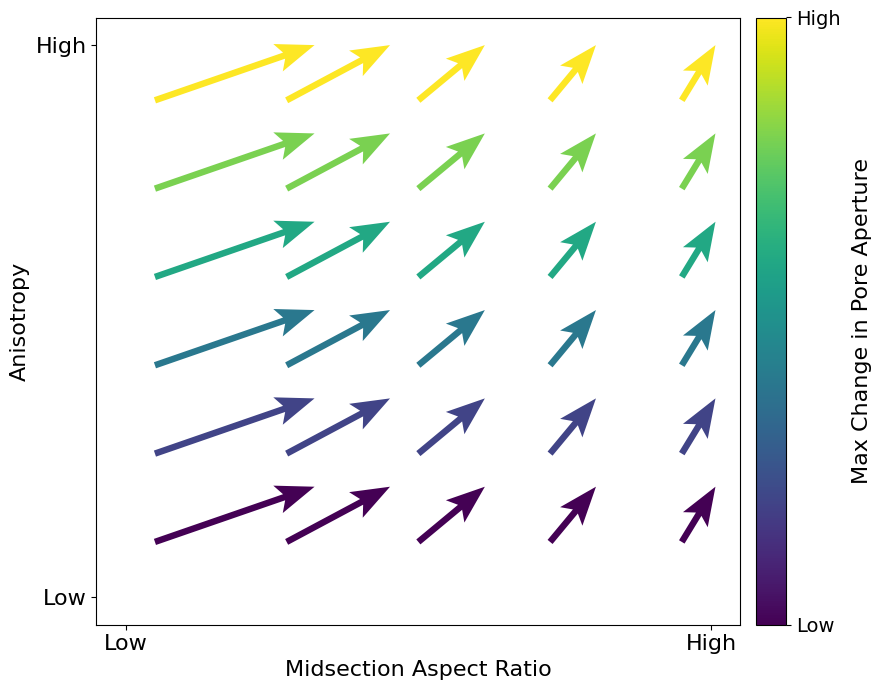

Arrow interpretation:
- All arrows reach the same vertical distance
- Steeper, shorter arrows = higher aspect ratio = faster opening
- Longer, shallower arrows = lower aspect ratio = slower opening
- Color = maximum pore aperture (anisotropy effect)

Speed range: 0.37 to 1.74 (4.7x difference)
Slope range: 0.37 to 1.74 (4.7x difference)
Arrow length range: 0.115 to 0.290

Slope by column (left to right):
  Column 1: slope = 0.37
  Column 2: slope = 0.57
  Column 3: slope = 0.88
  Column 4: slope = 1.28
  Column 5: slope = 1.74


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Reduced grid for better spacing and clearer slope differences
nx, ny = 5, 6  # fewer columns for better spacing
X, Y = np.meshgrid(np.linspace(0.05, 0.95, nx), np.linspace(0.1, 0.9, ny))

# Conceptual relationship:
# - Aspect ratio (X) determines RATE/SPEED of opening (slope)
# - Anisotropy (Y) determines MAX APERTURE (color)

# Define a fixed vertical distance all arrows should reach
target_height = 0.10

# Speed/rate with moderate, more linear progression
# More linear change = easier to see each step
speed = 0.35 + 1.5*X**1.5  # More linear (exponent 1.5), moderate range

# For arrows to reach the same height with different slopes:
V_final = np.ones_like(X) * target_height  # fixed vertical component
U_final = V_final / speed  # horizontal component inversely proportional to speed

# Color represents max aperture increasing with anisotropy (Y)
aperture = 0.2 + 0.8*Y

fig, ax = plt.subplots(figsize=(9, 7))
q = ax.quiver(
    X, Y, U_final, V_final, aperture, 
    scale=1.0,
    cmap='viridis', 
    width=0.010,
    headwidth=4.5,
    headlength=6,
    headaxislength=5,
    angles='xy',
    scale_units='xy'
)

ax.set_xlabel('Midsection Aspect Ratio', fontsize=16)
ax.set_ylabel('Anisotropy', fontsize=16)

# Clean axes
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=16)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=16)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# Colorbar with labels
cbar = plt.colorbar(q, ax=ax, label='Max Change in Pore Aperture', pad=0.02)
cbar.set_label('Max Change in Pore Aperture', fontsize=16, labelpad=8)
cbar.set_ticks([aperture.min(), aperture.max()])
cbar.set_ticklabels(['Low', 'High'], fontsize=14)


# Add clearer annotations with arrows pointing to examples
#ax.annotate('Slow opening\n(long, shallow)', xy=(0.12, 0.5), xytext=(0.25, 0.2),
#            fontsize=12, ha='center', style='italic', alpha=0.8,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor='gray'),
#            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='gray', lw=1.5))

#ax.annotate('Fast opening\n(short, steep)', xy=(0.88, 0.5), xytext=(0.75, 0.2),
#            fontsize=12, ha='center', style='italic', alpha=0.8,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor='gray'),
#            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color='gray', lw=1.5))

plt.tight_layout()
plt.savefig("concept.png", dpi=300, bbox_inches='tight')
plt.show()

# Diagnostic info
slopes = V_final / U_final
lengths = np.sqrt(U_final**2 + V_final**2)
print("Arrow interpretation:")
print("- All arrows reach the same vertical distance")
print("- Steeper, shorter arrows = higher aspect ratio = faster opening")
print("- Longer, shallower arrows = lower aspect ratio = slower opening")
print("- Color = maximum pore aperture (anisotropy effect)")
print(f"\nSpeed range: {speed.min():.2f} to {speed.max():.2f} ({speed.max()/speed.min():.1f}x difference)")
print(f"Slope range: {slopes.min():.2f} to {slopes.max():.2f} ({slopes.max()/slopes.min():.1f}x difference)")
print(f"Arrow length range: {lengths.min():.3f} to {lengths.max():.3f}")
print(f"\nSlope by column (left to right):")
for i in range(nx):
    print(f"  Column {i+1}: slope = {slopes[0, i]:.2f}")

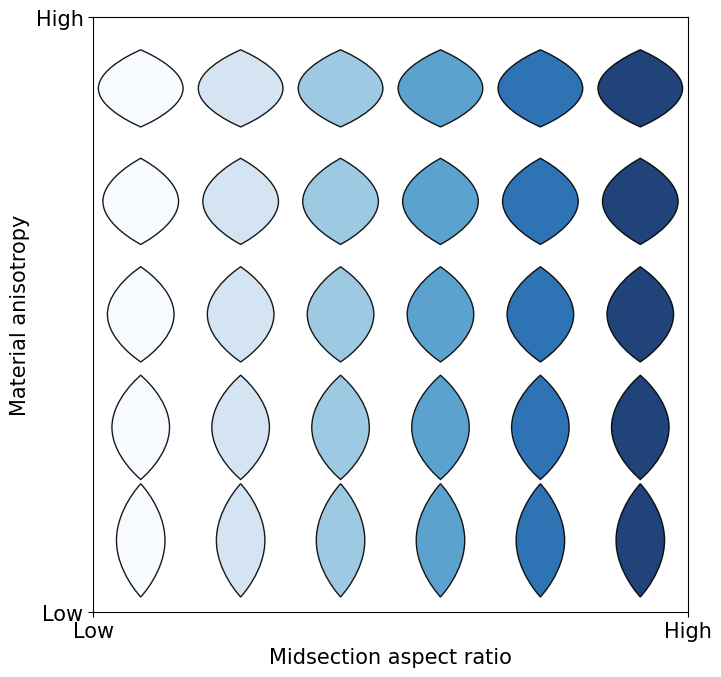

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cm as cm

def tapered_pore(center, width, height, color, alpha=0.9, edge='k'):
    x0, y0 = center
    rx = width / 2
    ry = height / 2

    k = 0.5522847498  # ellipse Bezier constant

    verts = [
        # Start at left
        (x0 - rx, y0),

        # Left → top cusp
        (x0 - rx, y0 + k * ry),
        (x0, y0 + ry),        # control collapsed
        (x0, y0 + ry),        # cusp point

        # Top cusp → right
        (x0, y0 + ry),        # control collapsed
        (x0 + rx, y0 + k * ry),
        (x0 + rx, y0),

        # Right → bottom cusp
        (x0 + rx, y0 - k * ry),
        (x0, y0 - ry),        # control collapsed
        (x0, y0 - ry),        # cusp point

        # Bottom cusp → left
        (x0, y0 - ry),        # control collapsed
        (x0 - rx, y0 - k * ry),
        (x0 - rx, y0),
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,
    ]

    return PathPatch(
        Path(verts, codes),
        facecolor=color,
        edgecolor=edge,
        linewidth=1.0,
        alpha=alpha
    )

# Conceptual plot with ovals showing final pore geometry (shape) vs pressure sensitivity
nx, ny = 6, 5
x = np.linspace(0.08, 0.92, nx)  # pressure requirement (low -> high)
y = np.linspace(0.12, 0.88, ny)  # final pore shape (eccentric -> circular)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(9, 7))
norm = plt.Normalize(vmin=x.min(), vmax=x.max())
cmap = cm.Blues

base_height = 0.20          # tallest pore length (bottom rows)
base_width = 0.16           # baseline width before oval adjustment
min_width_ratio = 0.45      # very slit-like
max_width_ratio = 0.95      # nearly circular
min_height_scale = 0.6      # shortest pore length at highest y

for xi, yi in zip(X.ravel(), Y.ravel()):
    width_ratio = min_width_ratio + (max_width_ratio - min_width_ratio) * yi
    height_scale = min_height_scale + (1 - yi) * (1 - min_height_scale)
    ellipse =tapered_pore(
    (xi, yi),
    width=base_width * width_ratio,
    height=base_height * height_scale,
    color=cmap(norm(xi)),
    edge='k',
    alpha=0.9,
    )
    ax.add_patch(ellipse)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=15)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=15)
ax.set_xlabel('Midsection aspect ratio', fontsize=15)
ax.set_ylabel('Material anisotropy', fontsize=15)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('concept_ovals.png', dpi=300, bbox_inches='tight')
plt.show()


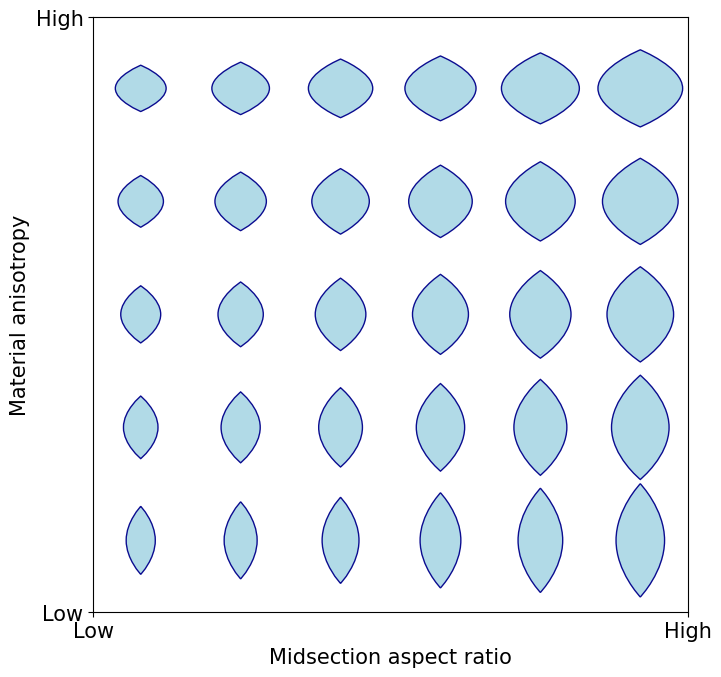

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Conceptual plot: oval shape encodes final geometry, oval size encodes pressure sensitivity
nx, ny = 6, 5
x = np.linspace(0.08, 0.92, nx)  # pressure requirement (low -> high)
y = np.linspace(0.12, 0.88, ny)  # final pore shape (eccentric -> circular)
X, Y = np.meshgrid(x, y)

fig, ax = plt.subplots(figsize=(9, 7))

base_height = 0.20          # tallest pore length (bottom rows)
base_width = 0.16
min_width_ratio = 0.45
max_width_ratio = 0.95
min_height_scale = 0.6

min_size_scale = 0.6
max_size_scale = 1.0

for xi, yi in zip(X.ravel(), Y.ravel()):
    width_ratio = min_width_ratio + (max_width_ratio - min_width_ratio) * yi
    height_scale = min_height_scale + (1 - yi) * (1 - min_height_scale)
    size_scale = min_size_scale + (xi - x.min()) / (x.max() - x.min()) * (max_size_scale - min_size_scale)
    ellipse = tapered_pore(
    (xi, yi),
    width=base_width * width_ratio * size_scale,
    height=base_height * height_scale * size_scale,
    color='lightblue',
    edge='darkblue',
    alpha=0.95,
)
    ax.add_patch(ellipse)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=15)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=15)
ax.set_ylabel('Material anisotropy', fontsize=15)
ax.set_xlabel('Midsection aspect ratio', fontsize=15)
ax.set_aspect('equal')

# Build legend-like proxy for size encoding
size_examples = np.linspace(min_size_scale, max_size_scale, 3)
handles = []
for scale in size_examples:
    handles.append(
        Ellipse((0, 0),
                width=base_width * size_scale,
                height=base_height * size_scale,
                facecolor='lightgray', edgecolor=cmap(scale), linewidth=1.3)
    )

legend_labels = ['Low sensitivity', 'Moderate', 'High sensitivity']
legend = ax.legend(handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, title='Oval size = sensitivity')
ax.add_artist(legend)

plt.tight_layout()
plt.savefig('concept_ovals_size.png', dpi=300, bbox_inches='tight')


In [7]:
## Can we determine from the geometry why some meshes fail when created idealised versions?
import pandas as pd

df_confocal = pd.read_csv("../output/confocal_results_df_batch.csv")
df_confocal_vals = df_confocal[df_confocal["Pressure"] == 0.0].copy()
df_confocal_vals.sort_values(by = "Pore Area", ascending=False)

,Mesh ID,Cross-section type,Pressure,Midsection AR left,Midsection AR right,Midsection Points Left,Midsection Points Right,Tip AR left,Tip AR right,Tip Points Left,Tip Points Right,Major length left,Major length right,Minor length left,Minor length right,Pore Area,Volume,Spline length
149,2_3,confocal,0.0,1.403737,1.324596,[[ 6.56129260e+00 9.65099062e+00 9.82587149e...,[[ 2.35775951e+01 5.56761763e+00 -8.12206481e...,1.107909,1.019385,[[ 6.64831835 -2.65717071 -7.14977591]\n [ 6.4...,[[ 24.11264519 23.11413461 -6.7559464 ]\n [ ...,14.160910,16.105473,10.088008,12.158777,74.04,12760.779552,76.043573
144,2_1,confocal,0.0,1.385808,1.369058,[[ -3.78366896 7.23714757 -10.82123327]\n [ ...,[[ 7.81825287 5.68627902 -5.57098611]\n [ ...,1.072043,1.094608,[[ -4.93568033 -3.66844203 2.1397736 ]\n [ ...,[[ 1.28640219e+01 2.23724794e+01 -5.19005830e...,13.745936,13.627392,9.919080,9.953845,73.87,8766.184804,71.336833
110,1_8,confocal,0.0,1.180437,1.354754,[[-3.69385497 4.84518801 -5.74617219]\n [-3.6...,[[ 1.05011301e+01 -9.10767135e+00 -4.72069349e...,1.154917,1.165958,[[-8.87295539e+00 -1.27162308e+01 -5.35936819e...,[[ 2.13632427e+01 4.58124595e+00 6.13095365e...,14.238902,15.806495,12.062399,11.667430,65.60,12229.323318,74.863024
101,1_6,confocal,0.0,1.410635,1.115640,[[-1.88313288e+01 -3.66517626e+00 2.58489005e...,[[ 4.30080362 2.32819203 6.12032783]\n [ 4.4...,1.140617,1.058870,[[ 3.93776514e-01 -8.16194144e+00 2.35966786e...,[[ 1.69984183e+00 2.00755683e+01 8.61321479e...,16.572904,14.542924,11.748544,13.035500,53.92,11428.902453,78.842037
76,1_5,confocal,0.0,1.442042,1.429982,[[-10.33727894 -1.05233497 -4.81608422]\n [-...,[[20.68991835 3.30925921 -2.73709874]\n [20.7...,1.021362,1.149113,[[ 1.06424078e+00 -8.32434021e+00 2.15744529e...,[[ 5.6371309 15.52488785 7.54245923]\n [ 5.7...,17.746883,18.018325,12.306769,12.600382,49.49,13939.597169,80.374448
200,2_7,confocal,0.0,1.340464,1.302316,[[ 27.5763478 4.93729766 -7.38062637]\n [ ...,[[ 44.14211591 2.62813946 -13.78794066]\n [ ...,1.028325,0.996025,[[ 2.45529719e+01 -1.01274454e+01 1.64405726e...,[[ 32.22846728 10.74268644 -9.49996039]\n [ ...,13.762323,13.704728,10.266833,10.523354,49.29,14585.898388,73.192492
22,1_3,confocal,0.0,1.452477,1.536301,[[-1.73107135e+01 2.07258757e+00 1.94202571e...,[[13.25824017 -1.13768809 -5.61404549]\n [13.4...,0.874767,1.059670,[[ -7.81823961 -18.07991109 -2.99135387]\n [ ...,[[ 2.18881679 6.46438584 1.06326348]\n [ 2.1...,15.849582,16.315589,10.912104,10.620049,44.65,11131.428457,74.646729
56,1_4,confocal,0.0,1.240656,1.199449,[[-16.63486953 -3.06713605 1.15134859]\n [-...,[[ 1.09030393e+01 3.59329852e-01 -5.34063910e...,1.004522,1.230358,[[ 3.09284096e-01 -7.57305913e+00 1.89148113e...,[[ 2.21184889 11.73113226 -4.94812643]\n [ 2.1...,15.337308,14.811966,12.362260,12.348979,42.91,10324.695350,72.143519
7,1_2,confocal,0.0,1.547294,1.614322,[[ -7.18079218 -0.99367801 3.9374313 ]\n [ ...,[[ 7.23202691e+00 -9.33082222e-03 4.20772201e...,1.035408,1.187306,[[ 0.90104596 -7.01635643 -2.00160326]\n [ ...,[[ 6.70981084 14.64599495 7.74335356]\n [ 6.8...,16.176377,17.431054,10.454621,10.797753,40.92,11304.069030,76.177412
258,3_6,confocal,0.0,1.258358,1.177384,[[-4.68356919e-01 -2.39911736e+00 -5.62678648e...,[[ 4.28289725e+00 1.11207872e+01 6.12649299e...,1.129388,1.238146,[[ 1.69907201e+01 -2.44615114e+00 6.26661544e...,[[-8.66814771e+00 1.58326822e+01 8.02852874e...,17.498386,17.012650,13.905728,14.449531,37.40,13581.585215,78.373875


In [34]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
import random

# Create the PDF
pdf_path = "Year9_Maths_Test_Week.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=A4)
styles = getSampleStyleSheet()
elements = []

# Title
title = Paragraph("<b>Year 9 Maths Test – Week</b>", styles['Title'])
elements.append(title)
elements.append(Spacer(1, 12))

# Name and Date lines
elements.append(Paragraph("Name: ____________________________", styles['Normal']))
elements.append(Paragraph("Date: ____________________________", styles['Normal']))
elements.append(Spacer(1, 12))

# Section 1: Mixed Arithmetic
elements.append(Paragraph("<b>Section 1: Mixed Arithmetic</b>", styles['Heading2']))
elements.append(Paragraph("Solve the following problems:", styles['Normal']))
elements.append(Spacer(1, 8))

# Generate 30 arithmetic questions (slightly more challenging)
questions = []
ops = ['×', '÷', '+', '-']
for i in range(30):
    a, b = random.randint(5, 20), random.randint(2, 12)
    op = random.choice(ops)
    if op == '÷':
        a = a * b  # make sure it's divisible
    questions.append(f"{i+1}.  {a} {op} {b} = __________")

# Arrange in two columns
mid = len(questions) // 2
table_data = [[Paragraph(q1, styles['Normal']), Paragraph(q2, styles['Normal'])]
              for q1, q2 in zip(questions[:mid], questions[mid:])]

table = Table(table_data, colWidths=[260, 260])
table.setStyle(TableStyle([
    ('VALIGN', (0, 0), (-1, -1), 'TOP'),
    ('LEFTPADDING', (0, 0), (-1, -1), 10),
    ('RIGHTPADDING', (0, 0), (-1, -1), 10),
]))
elements.append(table)
elements.append(Spacer(1, 20))

# Section 2: Word Problems
elements.append(Paragraph("<b>Section 2: Word Problems</b>", styles['Heading2']))
elements.append(Spacer(1, 8))

word_problems = [
    "1. A rectangle has a length of 12 cm and a width of 7 cm. What is its area and perimeter?",
    "2. A car travels 150 km in 3 hours. What is its average speed in km/h?",
    "3. The ratio of boys to girls in a class is 3:5. If there are 24 girls, how many boys are there?",
    "4. A laptop is discounted by 15% from its original price of £600. What is the new price?",
    "5. The volume of a cube is 125 cm³. What is the length of one side of the cube?"
]

for wp in word_problems:
    elements.append(Paragraph(wp, styles['Normal']))
    elements.append(Spacer(1, 8))
    elements.append(Paragraph("Answer: ________________________________________________", styles['Normal']))
    elements.append(Spacer(1, 8))

# Build the document
doc.build(elements)
print(f"✅ Year 9 Maths Test created: {pdf_path}")


✅ Year 9 Maths Test created: Year9_Maths_Test_Week.pdf
